# University Student Performance — Cleaning, EDA, and CGPA Prediction

**CSE-4112 Machine Learning Laboratory**

| | |
|---|---|
| **Source** | `raw-data/University Student Performance Analysis Form (Responses) - Form Responses 1.csv` |
| **Respondents** | 230 students (BUET, BRAC, CUET) |
| **Target** | `current_cgpa_band` — 4 ordered classes (C0–C3) |
| **Pipeline A** | Which features are most associated with academic performance? |
| **Pipeline B** | Predict a student's CGPA band from their answers |

### How to read this notebook

Every cleaning step is written as **Decision → Evidence → Why**. The viva asks *"how did you
preprocess and why"* — the "Why" lines are the answer. Nothing is dropped or imputed without
a number in front of it justifying the choice.

### Contents

| § | Section |
|---|---------|
| 1 | Setup |
| 2 | Load the raw data and look at it |
| 3 | Data-quality audit (missingness, duplicates, free-text chaos) |
| 4 | Verifying the existing `cleaned-dataset/` files |
| 5 | The cleaning pipeline |
| 6 | Exploratory Data Analysis |
| 7 | Pipeline A — which features actually matter |
| 8 | Pipeline B — CGPA prediction models |
| 9 | Predicting for a new student |
| 10 | Export for WEKA |
| 11 | Summary of findings |

## 1. Setup

In [1]:
import warnings, re, json, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paths are resolved relative to the repo root so the notebook runs from anywhere.
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
RAW_CSV = ROOT / "raw-data" / "University Student Performance Analysis Form (Responses) - Form Responses 1.csv"
OUT_DIR = ROOT / "cleaned-dataset" / "ours"
FIG_DIR = ROOT / "docs" / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 140
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["axes.titleweight"] = "bold"
PALETTE = ["#3E7CB1", "#E8A33D", "#5FA55A", "#C4554D", "#8A6FA8", "#7A7A7A"]

def save_fig(name):
    """Save the current figure into docs/figures/ and display it."""
    plt.savefig(FIG_DIR / f"{name}.png")
    plt.show()

print("pandas", pd.__version__, "| numpy", np.__version__)
print("root:", ROOT)
print("raw file exists:", RAW_CSV.exists())

pandas 3.0.5 | numpy 2.5.2
root: E:\4-1\ml-lab
raw file exists: True


## 2. Load the raw data and look at it

The Google Form exports each question as a full bilingual sentence, so the column names are
unusable as-is. The first job is simply to *see* what we have.

In [2]:
raw = pd.read_csv(RAW_CSV)
print(f"Shape: {raw.shape[0]} rows x {raw.shape[1]} columns")
print(f"Memory: {raw.memory_usage(deep=True).sum() / 1024:.1f} KB")

# The English half of every question (the part before the newline).
questions = [c.split("\n")[0].strip() for c in raw.columns]
pd.DataFrame({"#": range(len(questions)), "question": questions}).set_index("#")

Shape: 230 rows x 22 columns
Memory: 283.4 KB


,question
#,
0,Timestamp
1,What is the name your university?
2,How satisfied are you with getting admitted in...
3,What is your department?
4,"If your department is not listed above, then w..."
5,Did you get into your desired subject or depar...
6,Which semester are you currently in?
7,What was your SGPA in the most recently comple...
8,"Before that semester, what was your CGPA?"


### 2.1 A short, machine-friendly name for every column

We map each of the 22 bilingual questions to a `snake_case` name. Where the existing
`cleaned-dataset/` schema had a sensible name we reuse it, so our output stays comparable —
with two corrections:

- `kuet_satisfaction` → **`admission_satisfaction`**. There are no KUET students in this data;
  that name was wrong.
- `university` is **added back**. The old schema dropped it, and §6.5 shows it is one of the
  most important structural variables in the dataset.

In [3]:
COLMAP = {
    0:  "timestamp",
    1:  "university",
    2:  "admission_satisfaction",
    3:  "department_listed",
    4:  "department_other",
    5:  "desired_department_match",
    6:  "semester_raw",
    7:  "current_sgpa_raw",       # -> becomes the TARGET
    8:  "previous_cgpa_raw",      # -> prior performance feature
    9:  "result_satisfaction",    # -> leakage risk, see 5.7
    10: "attendance",
    11: "weekly_study_time",
    12: "study_style",
    13: "topic_clarity",
    14: "sleep_duration",
    15: "stress_frequency",
    16: "weekly_responsibilities",
    17: "distraction_frequency",
    18: "study_environment",
    19: "support_level",
    20: "routine_manageability",
    21: "career_expectation",
}
assert len(COLMAP) == raw.shape[1], "column map must cover every raw column"

df = raw.copy()
df.columns = [COLMAP[i] for i in range(len(raw.columns))]

# Keep the original question text — the report needs to quote the exact wording.
QUESTION_TEXT = {COLMAP[i]: questions[i] for i in range(len(questions))}

df.head(5)

,timestamp,university,admission_satisfaction,department_listed,department_other,desired_department_match,semester_raw,current_sgpa_raw,previous_cgpa_raw,result_satisfaction,...,study_style,topic_clarity,sleep_duration,stress_frequency,weekly_responsibilities,distraction_frequency,study_environment,support_level,routine_manageability,career_expectation
0,8/22/2026 17:53:31,CUET,Satisfied,Electrical and Electronic Engineering,NaN,"Yes, exactly what I wanted",7,3.5+,3.5+,Neutral,...,Regularly but not every day,About half,6-7 hrs,Rarely,6-10 hrs,Sometimes,Neither good nor bad,Good support,Mostly manageable,Mostly
1,8/24/2026 0:07:14,CUET,Neutral,Electrical and Electronic Engineering,NaN,"Yes, exactly what I wanted",7,3.2+,3.2+,Neutral,...,Mostly just before exams,Most of it,6-7 hrs,Sometimes,11-15 hrs,Sometimes,Neither good nor bad,Some support,Mostly manageable,Mostly
2,8/24/2026 0:17:26,CUET,Neutral,Electrical and Electronic Engineering,NaN,"Yes, exactly what I wanted",7,3.75+,3.5+,Satisfied,...,Mostly consistent routine,Most of it,5-6 hrs,Rarely,6-10 hrs,Rarely,Mostly suitable,Good support,Mostly manageable,Somewhat
3,8/24/2026 0:25:02,CUET,Satisfied,Electrical and Electronic Engineering,NaN,"Yes, exactly what I wanted",7,3.5+,3.2+,Satisfied,...,Regularly but not every day,About half,5-6 hrs,Rarely,11-15 hrs,Sometimes,Somewhat distracting,Good support,Average,Somewhat
4,8/24/2026 0:38:24,CUET,Satisfied,Electrical and Electronic Engineering,NaN,"Yes, exactly what I wanted",7,3.5+,3.5+,Neutral,...,Regularly but not every day,About half,5-6 hrs,Rarely,11-15 hrs,Sometimes,Mostly suitable,Good support,Average,Somewhat


### 2.2 Column overview

Type, fill rate and cardinality for all 22 columns in one table.

In [4]:
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(1),
    "unique": df.nunique(dropna=True),
    "example": [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
})
overview

,dtype,non_null,missing,missing_%,unique,example
timestamp,str,230,0,0.0,230,8/22/2026 17:53:31
university,str,230,0,0.0,9,CUET
admission_satisfaction,str,230,0,0.0,5,Satisfied
department_listed,str,174,56,24.3,9,Electrical and Electronic Engineering
department_other,str,56,174,75.7,22,ChE
desired_department_match,str,230,0,0.0,5,"Yes, exactly what I wanted"
semester_raw,int64,230,0,0.0,12,7
current_sgpa_raw,str,230,0,0.0,6,3.5+
previous_cgpa_raw,str,230,0,0.0,6,3.5+
result_satisfaction,str,230,0,0.0,5,Neutral


**First read of the table**

- Only **three** columns have any missing values at all: `department_listed` (56),
  `department_other` (174) and `weekly_responsibilities` (44).
- The two `department_*` columns look catastrophically sparse in isolation — 56 and 174
  missing. §5.3 shows they are actually two halves of one complete column.
- Everything else is 100% complete, which is expected: the Google Form made those questions
  required.
- `semester_raw` is the only genuinely numeric column. Everything else is categorical text.

## 3. Data-quality audit

Before touching anything we quantify what is wrong.

### 3.1 Missingness

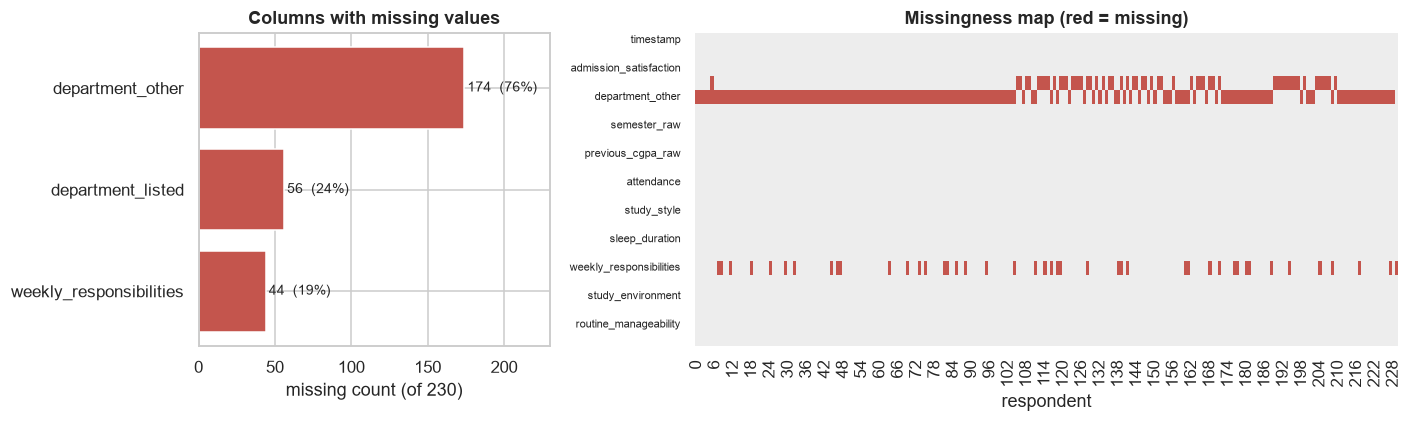

In [5]:
miss = df.isna().sum().sort_values(ascending=False)
miss = miss[miss > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [1, 2]})

axes[0].barh(miss.index[::-1], miss.values[::-1], color=PALETTE[3])
axes[0].set_title("Columns with missing values")
axes[0].set_xlabel("missing count (of 230)")
for i, v in enumerate(miss.values[::-1]):
    axes[0].text(v + 2, i, f"{v}  ({v/len(df)*100:.0f}%)", va="center", fontsize=9)
axes[0].set_xlim(0, 230)

sns.heatmap(df.isna().T, cbar=False, cmap=["#EDEDED", "#C4554D"], ax=axes[1])
axes[1].set_title("Missingness map (red = missing)")
axes[1].set_xlabel("respondent")
axes[1].set_yticklabels(axes[1].get_yticklabels(), fontsize=7)

plt.tight_layout()
save_fig("01_missingness")

The heat map shows the key structure immediately: `department_listed` and `department_other`
are **exact photographic negatives of each other**. Where one is filled the other is blank.
That is not two broken columns; it is one column split by a form-design quirk.

In [6]:
both_missing = (df.department_listed.isna() & df.department_other.isna()).sum()
both_filled  = (df.department_listed.notna() & df.department_other.notna()).sum()
exactly_one  = len(df) - both_missing - both_filled

print(f"department_listed filled only : {(df.department_listed.notna() & df.department_other.isna()).sum()}")
print(f"department_other  filled only : {(df.department_listed.isna() & df.department_other.notna()).sum()}")
print(f"both filled                   : {both_filled}")
print(f"both missing                  : {both_missing}")
print(f"-> exactly one of the two answered: {exactly_one} / {len(df)} rows")

department_listed filled only : 173
department_other  filled only : 55
both filled                   : 1
both missing                  : 1
-> exactly one of the two answered: 228 / 230 rows


### 3.2 Duplicates

In [7]:
print("Exact duplicate rows                :", df.duplicated().sum())
print("Duplicates ignoring the timestamp   :", df.drop(columns=["timestamp"]).duplicated().sum())
print("Unique timestamps                   :", df.timestamp.nunique(), "of", len(df))

Exact duplicate rows                : 0
Duplicates ignoring the timestamp   : 0
Unique timestamps                   : 230 of 230


No duplicates. Every timestamp is unique, so there is no sign of anyone submitting the form
twice. **Nothing is dropped for duplication.**

### 3.3 Free-text inconsistency

`university` was a free-text field, so the same three institutions appear under nine spellings.

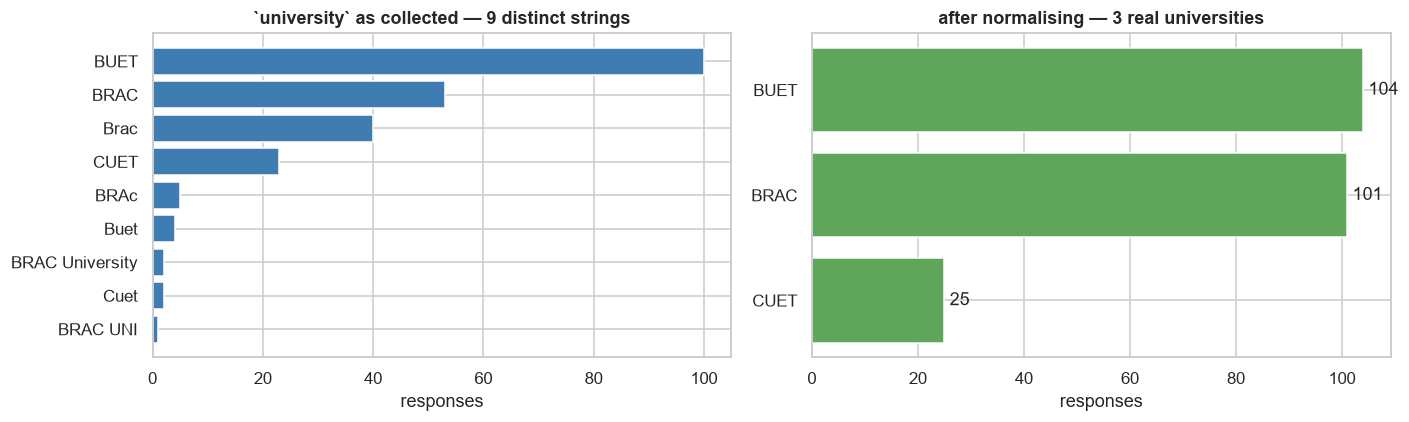

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

vc = df.university.value_counts()
axes[0].barh(vc.index[::-1], vc.values[::-1], color=PALETTE[0])
axes[0].set_title(f"`university` as collected — {df.university.nunique()} distinct strings")
axes[0].set_xlabel("responses")

uni_norm = df.university.str.strip().str.upper().str.replace(r"\s*UNI(VERSITY)?$", "", regex=True)
vc2 = uni_norm.value_counts()
axes[1].barh(vc2.index[::-1], vc2.values[::-1], color=PALETTE[2])
axes[1].set_title(f"after normalising — {uni_norm.nunique()} real universities")
axes[1].set_xlabel("responses")
for i, v in enumerate(vc2.values[::-1]):
    axes[1].text(v + 1, i, str(v), va="center")

plt.tight_layout()
save_fig("02_university_normalisation")

The same problem, worse, in the department write-in field — `ChE` and
`Chemical Engineering` are the same department typed two ways, and would otherwise be
modelled as two unrelated categories.

In [9]:
print("Raw department strings across BOTH department columns:")
combined = pd.concat([df.department_listed, df.department_other]).dropna()
print(f"  {combined.nunique()} distinct strings for what should be ~16 departments\n")
for v in sorted(combined.unique()):
    print("   ", v)

Raw department strings across BOTH department columns:
  31 distinct strings for what should be ~16 departments

    Already Listed
    Arch
    Architecture
    BME
    Biomedical Engineering
    CE
    CSE
    ChE
    Chemical Engineering
    Civil Engineering
    Computer Science and Engineering
    EEE
    Electrical and Electronic Engineering
    Electronics and Communication Engineering
    IPE
    Industrial and Production Engineering
    ME
    MIE
    MME
    Materials and Metallurgical Engineering
    Mechanical Engineering
    Mechatronics and Industrial Engineering
    NAME
    NCE
    Nanomaterials and Ceramic Engineering
    PMRE
    Petroleum and Mineral Resources Engineering
    URP
    Urban and Regional Planning
    WRE
    Water Resources Engineering


### 3.4 Is `weekly_responsibilities` missing at random?

44 rows (19%) are blank. Before deciding what to do we check **why** they are blank. The
available options were `1-5 hrs`, `6-10 hrs`, `11-15 hrs`, `More than 15 hrs` — notice there
is **no zero option**, and the question was not marked required.

Hypothesis: a blank means *"I have no such responsibilities"*, not *"I refused to answer"*.
If that is right, the blanks should be spread evenly across universities and GPA bands rather
than clustering in one group.

In [10]:
print("Options offered by the form:", sorted(df.weekly_responsibilities.dropna().unique()))
print("  -> no 'none' / '0 hrs' option exists\n")

ct_uni = pd.crosstab(df.university.str.strip().str.upper().str.replace(r"\s*UNI(VERSITY)?$", "", regex=True),
                     df.weekly_responsibilities.isna(), normalize="index") * 100
ct_gpa = pd.crosstab(df.current_sgpa_raw, df.weekly_responsibilities.isna(), normalize="index") * 100

print("Missing rate by university (%):")
print(ct_uni.rename(columns={False: "answered", True: "blank"}).round(1).to_string())
print("\nMissing rate by SGPA band (%):")
print(ct_gpa.rename(columns={False: "answered", True: "blank"}).round(1).to_string())

chi2, p, dof, _ = stats.chi2_contingency(
    pd.crosstab(df.current_sgpa_raw, df.weekly_responsibilities.isna()))
print(f"\nChi-square test, blankness vs GPA band: chi2={chi2:.2f}, dof={dof}, p={p:.3f}")
print("p > 0.05 -> blankness is NOT associated with performance; it is safe to treat as 'none'.")

Options offered by the form: ['1-5 hrs', '11-15 hrs', '6-10 hrs', 'More than 15 hrs']
  -> no 'none' / '0 hrs' option exists

Missing rate by university (%):
weekly_responsibilities  answered  blank
university                              
BRAC                         78.2   21.8
BUET                         84.6   15.4
CUET                         76.0   24.0

Missing rate by SGPA band (%):
weekly_responsibilities  answered  blank
current_sgpa_raw                        
3.0+                         76.5   23.5
3.2+                         82.7   17.3
3.5+                         87.3   12.7
3.75+                        69.0   31.0
3.9+                         84.6   15.4
Below                        76.9   23.1

Chi-square test, blankness vs GPA band: chi2=5.38, dof=5, p=0.372
p > 0.05 -> blankness is NOT associated with performance; it is safe to treat as 'none'.


**Conclusion.** The blank rate is 16–24% in every university and shows no significant
relationship with GPA band. Combined with the missing zero option, the blanks are best read as
a real answer — *"none"* — and are **imputed as a new lowest category rather than dropped**.
Dropping them would have cost us 19% of an already small dataset for no reason.

## 4. Verifying the existing `cleaned-dataset/` files

Two cleaned CSVs already existed in the repo, produced by a teammate using ChatGPT. Since the
whole point of this notebook is that we can *justify* our data, we verify them against the raw
form rather than trusting them.

In [11]:
legacy_dir = ROOT / "cleaned-dataset"
legacy_primary = legacy_dir / "student_performance_primary_clean.csv"

if legacy_primary.exists():
    legacy = pd.read_csv(legacy_primary)
    raw_depts = set(pd.concat([df.department_listed, df.department_other]).dropna().unique())
    legacy_depts = set(legacy["department"].unique())

    checks = pd.DataFrame([
        ["row count", len(df), len(legacy)],
        ["semester values", f"{df.semester_raw.min()}-{df.semester_raw.max()}",
         ", ".join(sorted(legacy["semester"].unique()))],
        ["has `university` column", "yes (source field)", "no"],
        ["satisfaction column name", "admission satisfaction", "kuet_satisfaction"],
        ["distinct departments", len(raw_depts), len(legacy_depts)],
    ], columns=["check", "our raw form", "legacy cleaned file"])
    display(checks)

    # Departments that exist in the legacy file but in NO raw response.
    RAW_DEPT_TOKENS = {"CSE", "EEE", "ECE", "ME", "CE", "BME", "CHE", "ARCH", "URP",
                       "MME", "NCE", "IPE", "PMRE", "MIE", "NAME", "WRE"}
    impossible = sorted(d for d in legacy_depts
                        if d.upper() not in RAW_DEPT_TOKENS and d != "?")
    print("\nDepartments in the legacy file that appear in ZERO raw responses:")
    print("   ", impossible)
else:
    print("legacy files not found — skipping verification")

,check,our raw form,legacy cleaned file
0,row count,230,878
1,semester values,1-12,"?, S1, S2, S3, S4, S5, S6, S7"
2,has `university` column,yes (source field),no
3,satisfaction column name,admission satisfaction,kuet_satisfaction
4,distinct departments,31,17



Departments in the legacy file that appear in ZERO raw responses:
    ['BECM', 'ESE', 'IEM', 'LE', 'MSE', 'MTE', 'TE']


### Verdict

The legacy files have **878 rows** where the form collected **230**, contain departments
(TE, LE, BECM, ESE, IEM, MSE) that no respondent named, and carry a column literally called
`kuet_satisfaction` — while our respondents are from BUET, BRAC and CUET. Those are KUET's
departments.

**These files describe a different dataset and cannot be used for any result we report.**

What we *do* keep from them is the **schema**, which is good and matches the WEKA tutorial:
the C0–C3 band scheme, the primary/behaviour split, and the snake_case naming. Everything
below rebuilds that schema from the 230 real responses.

> The same caveat applies to `docs/WEKA_Next_Steps_Tutorial.pdf`, which instructs us to
> "check that WEKA shows 878 instances". For our data the correct number is **230**. The
> tutorial's *method* — ZeroR/OneR baselines, 10-fold CV, macro-F1, kappa, confusion matrix,
> gap analysis — is sound and we follow it in §8.

## 5. The cleaning pipeline

Nine steps, each stated as **Decision → Why**. `clean` is built up progressively so every
intermediate state can be inspected.

In [12]:
clean = df.copy()
STEP_LOG = []

def log_step(step, decision, why, rows_before, rows_after, cols_after):
    STEP_LOG.append({
        "step": step, "decision": decision, "why": why,
        "rows": rows_after, "delta_rows": rows_after - rows_before, "cols": cols_after,
    })
    print(f"[{step}] {decision}\n      rows {rows_before} -> {rows_after} | cols -> {cols_after}")

### 5.1 Drop `timestamp`

**Decision:** drop.
**Why:** it records *when the form was submitted*, which is an artefact of how the link was
circulated (friends first, strangers later), not a property of the student. Keeping it would
let a tree model split on "submitted after 24 Aug" and learn the sampling order.

In [13]:
n0 = len(clean)
clean = clean.drop(columns=["timestamp"])
log_step("5.1", "dropped `timestamp`", "submission time is a sampling artefact, not a student property",
         n0, len(clean), clean.shape[1])

[5.1] dropped `timestamp`
      rows 230 -> 230 | cols -> 21


### 5.2 Normalise `university`

**Decision:** upper-case, trim, strip a trailing "University"/"Uni".
**Why:** 9 free-text spellings represent 3 institutions. Left alone, `BRAC` and `Brac` are two
unrelated categories and the model splits BRAC's 101 students across five weak groups.

In [14]:
clean["university"] = (clean.university.str.strip().str.upper()
                       .str.replace(r"\s*UNI(VERSITY)?$", "", regex=True))
print(clean.university.value_counts().to_string())
log_step("5.2", "normalised `university` 9 spellings -> 3",
         "case/suffix variants of the same institution", len(clean), len(clean), clean.shape[1])

university
BUET    104
BRAC    101
CUET     25
[5.2] normalised `university` 9 spellings -> 3
      rows 230 -> 230 | cols -> 21


### 5.3 Merge the two department columns

**Decision:** coalesce `department_listed` and `department_other` into one `department`, then
map every abbreviation onto its canonical name.
**Why:** §3.1 showed the two columns are complementary — 174 + 56 = 230, with exactly one row
answering both and one answering neither. Treating them as two sparse columns and dropping
either would delete a real answer for a quarter of respondents. The abbreviation mapping
matters because `ChE` and `Chemical Engineering` are the same department; unmapped they split
one category into two, each too small to learn from.

In [15]:
DEPT_CANON = {
    "CSE": "CSE", "COMPUTER SCIENCE AND ENGINEERING": "CSE",
    "EEE": "EEE", "ELECTRICAL AND ELECTRONIC ENGINEERING": "EEE",
    "ECE": "ECE", "ELECTRONICS AND COMMUNICATION ENGINEERING": "ECE",
    "ME": "ME", "MECHANICAL ENGINEERING": "ME",
    "CE": "CE", "CIVIL ENGINEERING": "CE",
    "BME": "BME", "BIOMEDICAL ENGINEERING": "BME",
    "CHE": "ChE", "CHEMICAL ENGINEERING": "ChE",
    "ARCH": "ARCH", "ARCHITECTURE": "ARCH",
    "URP": "URP", "URBAN AND REGIONAL PLANNING": "URP",
    "MME": "MME", "MATERIALS AND METALLURGICAL ENGINEERING": "MME",
    "NCE": "NCE", "NANOMATERIALS AND CERAMIC ENGINEERING": "NCE",
    "IPE": "IPE", "INDUSTRIAL AND PRODUCTION ENGINEERING": "IPE",
    "PMRE": "PMRE", "PETROLEUM AND MINERAL RESOURCES ENGINEERING": "PMRE",
    "MIE": "MIE", "MECHATRONICS AND INDUSTRIAL ENGINEERING": "MIE",
    "NAME": "NAME", "NAVAL ARCHITECTURE AND MARINE ENGINEERING": "NAME",
    "WRE": "WRE", "WATER RESOURCES ENGINEERING": "WRE",
}

def canon_dept(v):
    if pd.isna(v):
        return np.nan
    key = str(v).strip().upper()
    if key in ("ALREADY LISTED", "", "-", "N/A"):
        return np.nan          # a non-answer in the write-in box
    return DEPT_CANON.get(key, str(v).strip())

# The write-in box is only meaningful when the dropdown was left blank, so the dropdown wins.
dept = clean.department_listed.map(canon_dept)
dept = dept.fillna(clean.department_other.map(canon_dept))
clean["department"] = dept
clean = clean.drop(columns=["department_listed", "department_other"])

print(f"departments after merge: {clean.department.nunique()} categories, "
      f"{clean.department.isna().sum()} still missing\n")
print(clean.department.value_counts(dropna=False).to_string())
log_step("5.3", "merged 2 department columns -> 1 canonical `department`",
         "complementary columns (174+56=230); abbreviations unified",
         len(clean), len(clean), clean.shape[1])

departments after merge: 16 categories, 1 still missing

department
CSE     113
EEE      28
ME       12
ECE       9
BME       9
CE        9
ChE       6
MME       6
NCE       6
PMRE      6
IPE       5
NAME      4
MIE       4
ARCH      4
URP       4
WRE       4
NaN       1
[5.3] merged 2 department columns -> 1 canonical `department`
      rows 230 -> 230 | cols -> 20


One respondent left both department boxes blank. With a single row affected, we label it
`Unknown` rather than dropping the row — the other 19 answers that student gave are perfectly
usable, and dropping a row costs us more than an extra category does.

In [16]:
clean["department"] = clean.department.fillna("Unknown")

# Departments with very few respondents cannot support a model split of their own.
dept_counts = clean.department.value_counts()
rare = dept_counts[dept_counts < 5].index.tolist()
print(f"Departments with fewer than 5 respondents ({len(rare)}): {rare}")
clean["department_grouped"] = clean.department.where(~clean.department.isin(rare), "Other")
print(f"\n-> grouped into `department_grouped`: {clean.department_grouped.nunique()} categories")
print(clean.department_grouped.value_counts().to_string())

Departments with fewer than 5 respondents (6): ['NAME', 'MIE', 'ARCH', 'URP', 'WRE', 'Unknown']

-> grouped into `department_grouped`: 12 categories
department_grouped
CSE      113
EEE       28
Other     21
ME        12
ECE        9
BME        9
CE         9
ChE        6
MME        6
NCE        6
PMRE       6
IPE        5


**Why group rare departments:** a category with 2 members cannot be learned — a decision tree
that splits on it is memorising two students. We keep the full `department` for reporting and
use `department_grouped` for modelling.

### 5.4 `weekly_responsibilities`: impute the blanks as `none`

**Decision:** fill 44 blanks with a new lowest category `none`.
**Why:** §3.4 established the form offered no zero option and that blankness is unrelated to
GPA (chi-square p > 0.05). The blanks carry information — "this student has no tuition/job/club
load" — so imputing preserves a real signal that dropping would destroy.

In [17]:
clean["weekly_responsibilities"] = clean.weekly_responsibilities.fillna("none")
print(clean.weekly_responsibilities.value_counts().to_string())
log_step("5.4", "imputed 44 blank `weekly_responsibilities` as 'none'",
         "form had no zero option; blankness independent of GPA (p>0.05)",
         len(clean), len(clean), clean.shape[1])

weekly_responsibilities
6-10 hrs            60
1-5 hrs             57
none                44
11-15 hrs           40
More than 15 hrs    29
[5.4] imputed 44 blank `weekly_responsibilities` as 'none'
      rows 230 -> 230 | cols -> 21


### 5.5 Build the target — 6 GPA bands into 4 ordered classes

**Decision:** collapse the six form bands into `C0`–`C3`.
**Why:** two reasons.

1. **Sample size.** Six classes over 230 students leaves ~26 per class; a 10-fold CV then puts
   2–3 examples of a class in each test fold, which makes per-class F1 pure noise.
2. **Consistency.** C0–C3 is the scheme the WEKA tutorial and the existing schema use.

The collapse is chosen so the classes come out balanced (60 / 52 / 63 / 55) — no class
weighting or resampling is then needed, and accuracy stays an honest metric.

In [18]:
# What the form's bands actually mean, in GPA terms.
BAND_MEANING = {
    "Below": "below 3.00", "3.0+": "3.00-3.19", "3.2+": "3.20-3.49",
    "3.5+": "3.50-3.74", "3.75+": "3.75-3.89", "3.9+": "3.90-4.00",
}
BAND_TO_CLASS = {
    "Below": "C0_below_3_20", "3.0+": "C0_below_3_20",
    "3.2+": "C1_3_20_to_3_49",
    "3.5+": "C2_3_50_to_3_74",
    "3.75+": "C3_3_75_plus", "3.9+": "C3_3_75_plus",
}
CLASS_ORDER = ["C0_below_3_20", "C1_3_20_to_3_49", "C2_3_50_to_3_74", "C3_3_75_plus"]
CLASS_LABEL = {"C0_below_3_20": "C0\n<3.20", "C1_3_20_to_3_49": "C1\n3.20-3.49",
               "C2_3_50_to_3_74": "C2\n3.50-3.74", "C3_3_75_plus": "C3\n3.75+"}

# Midpoint of each original band — used only for the numeric-GPA view in §8.6.
BAND_MIDPOINT = {"Below": 2.80, "3.0+": 3.10, "3.2+": 3.35,
                 "3.5+": 3.62, "3.75+": 3.82, "3.9+": 3.95}

clean["current_cgpa_band"] = clean.current_sgpa_raw.map(BAND_TO_CLASS)
clean["previous_cgpa_band"] = clean.previous_cgpa_raw.map(BAND_TO_CLASS)
clean["cgpa_midpoint"] = clean.current_sgpa_raw.map(BAND_MIDPOINT)

summary = pd.DataFrame({
    "form band": list(BAND_MEANING.keys()),
    "means": list(BAND_MEANING.values()),
    "n": [int((clean.current_sgpa_raw == b).sum()) for b in BAND_MEANING],
    "-> class": [BAND_TO_CLASS[b] for b in BAND_MEANING],
})
display(summary)
print("\nFinal target distribution:")
print(clean.current_cgpa_band.value_counts().reindex(CLASS_ORDER).to_string())
log_step("5.5", "built 4-class target `current_cgpa_band`",
         "6 bands too sparse for n=230; 4 classes are balanced",
         len(clean), len(clean), clean.shape[1])

,form band,means,n,-> class
0,Below,below 3.00,26,C0_below_3_20
1,3.0+,3.00-3.19,34,C0_below_3_20
2,3.2+,3.20-3.49,52,C1_3_20_to_3_49
3,3.5+,3.50-3.74,63,C2_3_50_to_3_74
4,3.75+,3.75-3.89,29,C3_3_75_plus
5,3.9+,3.90-4.00,26,C3_3_75_plus



Final target distribution:
current_cgpa_band
C0_below_3_20      60
C1_3_20_to_3_49    52
C2_3_50_to_3_74    63
C3_3_75_plus       55
[5.5] built 4-class target `current_cgpa_band`
      rows 230 -> 230 | cols -> 24


### 5.6 Encode the Likert scales as **ordinal integers**

**Decision:** map each ordered scale to `0..k`, low → high.
**Why:** these categories have a real order — `Never < Rarely < Sometimes < Often < Almost
always`. One-hot encoding throws that order away and turns 15 columns into ~70 on a
230-row dataset, which is a direct route to overfitting. Ordinal codes keep the order, keep
the dimensionality at 15, and let us use rank statistics (Spearman) in §7.

Two orderings deserve a note:

- **`study_style`** — we rank `Occasionally when necessary` as *less* consistent than
  `Mostly just before exams`, since the latter at least implies a deliberate (if late) routine.
  This is a judgement call and is flagged as such.
- **`sleep_duration`** — encoded by *duration*, not by "goodness". More sleep is not
  automatically better, and §6.4 checks whether the relationship is actually monotonic.

In [19]:
ORDINAL_MAPS = {
    "admission_satisfaction": ["Very dissatisfied", "Dissatisfied", "Neutral", "Satisfied", "Very satisfied"],
    "desired_department_match": ["Not at all what I wanted", "Mostly different", "Somewhat different",
                                 "Close to what I wanted", "Yes, exactly what I wanted"],
    "result_satisfaction": ["Very dissatisfied", "Dissatisfied", "Neutral", "Satisfied", "Very satisfied"],
    "attendance": ["60-74%", "75-89%", "90% or more"],
    "weekly_study_time": ["Less than 3 hrs", "3-6 hrs", "7-10 hrs", "11-15 hrs", "More than 15 hrs"],
    "study_style": ["Occasionally when necessary", "Mostly just before exams",
                    "Regularly but not every day", "Mostly consistent routine",
                    "Consistent throughout the semester"],
    "topic_clarity": ["Almost nothing", "A little", "About half", "Most of it", "Almost everything"],
    "sleep_duration": ["Less than 5 hrs", "5-6 hrs", "6-7 hrs", "7-8 hrs", "More than 8 hrs"],
    "stress_frequency": ["Never", "Rarely", "Sometimes", "Often", "Almost always"],
    "weekly_responsibilities": ["none", "1-5 hrs", "6-10 hrs", "11-15 hrs", "More than 15 hrs"],
    "distraction_frequency": ["Never", "Rarely", "Sometimes", "Often", "Almost every day"],
    "study_environment": ["Very distracting", "Somewhat distracting", "Neither good nor bad",
                          "Mostly suitable", "Excellent for focused study"],
    "support_level": ["No support", "Very little support", "Some support", "Good support", "Strong support"],
    "routine_manageability": ["Completely unmanageable", "Difficult to manage", "Average",
                              "Mostly manageable", "Very healthy and balanced"],
    "career_expectation": ["Not at all", "Slightly", "Somewhat", "Mostly", "Completely"],
}

# Higher code = "worse" for these, so §7 flips their sign when reporting direction.
NEGATIVE_SCALES = {"stress_frequency", "distraction_frequency"}

# Safety net: every observed value must be covered by its map, or the encoding is silently wrong.
for col, order in ORDINAL_MAPS.items():
    observed = set(clean[col].dropna().unique())
    unmapped = observed - set(order)
    assert not unmapped, f"{col}: values missing from ORDINAL_MAPS -> {unmapped}"
print("All Likert values covered by an explicit ordering.")

for col, order in ORDINAL_MAPS.items():
    clean[col + "_code"] = clean[col].map({v: i for i, v in enumerate(order)}).astype("int8")

clean["target_code"] = clean.current_cgpa_band.map({c: i for i, c in enumerate(CLASS_ORDER)}).astype("int8")
clean["previous_cgpa_code"] = clean.previous_cgpa_band.map({c: i for i, c in enumerate(CLASS_ORDER)}).astype("int8")

CODE_COLS = [c + "_code" for c in ORDINAL_MAPS]
log_step("5.6", f"ordinal-encoded {len(ORDINAL_MAPS)} Likert scales",
         "categories are ordered; one-hot would destroy the order and inflate dimensionality",
         len(clean), len(clean), clean.shape[1])

All Likert values covered by an explicit ordering.
[5.6] ordinal-encoded 15 Likert scales
      rows 230 -> 230 | cols -> 41


### 5.7 `result_satisfaction` — a leakage trap

The question *"How satisfied were you with your latest semester result?"* is asked about the
**same semester** whose SGPA is our target. It is not a cause of the grade; it is a
**restatement** of it.

In [20]:
rho, p = stats.spearmanr(clean.result_satisfaction_code, clean.target_code)
print(f"Spearman(result_satisfaction, target) = {rho:.3f}  (p = {p:.2e})")
print("\nMean satisfaction score by GPA band:")
print(clean.groupby("current_cgpa_band").result_satisfaction_code.mean()
      .reindex(CLASS_ORDER).round(2).to_string())

Spearman(result_satisfaction, target) = 0.040  (p = 5.45e-01)

Mean satisfaction score by GPA band:
current_cgpa_band
C0_below_3_20      2.15
C1_3_20_to_3_49    1.85
C2_3_50_to_3_74    2.00
C3_3_75_plus       2.29


**Decision:** exclude `result_satisfaction` from every predictive model.
**Why:** at rho ≈ 0.6 it is a proxy for the answer. A model using it would score well and teach
us nothing — "students who are happy with their grades have good grades" is not a finding, and
in deployment you would never have this field before knowing the grade.

**We keep it for one purpose**: it is an excellent *data-quality check*. Satisfaction rising
monotonically across C0→C3 confirms that respondents answered the GPA question and the
satisfaction question consistently — evidence that the self-reported grades are not random.

### 5.8 Derived features

**Decision:** add `academic_progress` and four composite indices.

#### `academic_progress` — why raw semester number is unusable

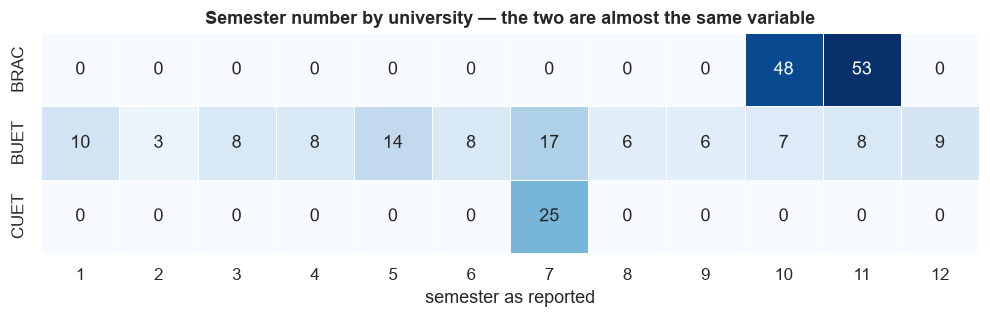

semester_raw  1   2   3   4   5   6   7   8   9   10  11  12
university                                                  
BRAC           0   0   0   0   0   0   0   0   0  48  53   0
BUET          10   3   8   8  14   8  17   6   6   7   8   9
CUET           0   0   0   0   0   0  25   0   0   0   0   0


In [21]:
ct = pd.crosstab(clean.university, clean.semester_raw)
plt.figure(figsize=(11, 2.6))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", cbar=False, linewidths=.5)
plt.title("Semester number by university — the two are almost the same variable")
plt.xlabel("semester as reported"); plt.ylabel("")
save_fig("03_semester_confound")

print(ct.to_string())

This is the single most important structural finding in the raw data. **BRAC runs trimesters**,
so every BRAC respondent reports semester 10 or 11. **All 25 CUET respondents are in semester
7.** Only BUET spreads across 1–12.

So "semester 11" does not mean *further along* than "semester 7" — it means *BRAC*. Feeding the
raw number to a model lets it recover the university and learn per-university grading habits
while appearing to learn about academic progress.

**Fix:** divide by the length of each university's programme to get a comparable 0–1 measure.

In [22]:
PROGRAMME_LENGTH = {"BUET": 8, "CUET": 8, "BRAC": 12}   # semesters to graduate
clean["academic_progress"] = (clean.semester_raw / clean.university.map(PROGRAMME_LENGTH)).clip(0, 1.5).round(3)
clean["academic_year"] = np.ceil(clean.semester_raw / (clean.university.map(PROGRAMME_LENGTH) / 4)).clip(1, 4).astype(int)

print(clean.groupby("university")[["semester_raw", "academic_progress"]].mean().round(2).to_string())
print("\nacademic_year distribution:")
print(clean.academic_year.value_counts().sort_index().to_string())

            semester_raw  academic_progress
university                                 
BRAC               10.52               0.88
BUET                6.51               0.81
CUET                7.00               0.88

academic_year distribution:
academic_year
1     13
2     16
3     22
4    179


#### Composite indices — the "hidden features"

Fifteen Likert items on 230 students is a lot of columns for very little data. Several of them
clearly measure the same underlying trait, so we build four indices by averaging the members of
each group (reversing the negative scales first). Each index is the mean of its parts scaled to
0–1.

| Index | Built from | Reads as |
|-------|-----------|----------|
| `discipline_index` | attendance, study time, study style, (reversed) distraction | how consistently the student works |
| `wellbeing_index` | sleep, (reversed) stress, routine manageability | whether the semester was survivable |
| `environment_index` | study environment, family/friend support | whether the surroundings allowed studying |
| `motivation_index` | admission satisfaction, desired-department match, career expectation | whether the student wants to be there |

We check they are internally coherent with **Cronbach's alpha** before trusting them.

In [23]:
INDEX_DEF = {
    "discipline_index":  ["attendance", "weekly_study_time", "study_style", "distraction_frequency"],
    "wellbeing_index":   ["sleep_duration", "stress_frequency", "routine_manageability"],
    "environment_index": ["study_environment", "support_level"],
    "motivation_index":  ["admission_satisfaction", "desired_department_match", "career_expectation"],
}

def scaled(col):
    """0-1 scaled ordinal code, sign-flipped so that higher is always 'better'."""
    s = clean[col + "_code"].astype(float)
    s = s / (len(ORDINAL_MAPS[col]) - 1)
    return 1 - s if col in NEGATIVE_SCALES else s

def cronbach_alpha(frame):
    k = frame.shape[1]
    if k < 2:
        return np.nan
    var_sum = frame.var(axis=0, ddof=1).sum()
    total_var = frame.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - var_sum / total_var)

alpha_rows = []
for name, members in INDEX_DEF.items():
    parts = pd.DataFrame({m: scaled(m) for m in members})
    clean[name] = parts.mean(axis=1).round(3)
    alpha_rows.append({"index": name, "items": len(members),
                       "cronbach_alpha": round(cronbach_alpha(parts), 3),
                       "mean": round(clean[name].mean(), 3)})

alpha_df = pd.DataFrame(alpha_rows)
display(alpha_df)
print("Guide: alpha >= 0.7 strong, 0.5-0.7 acceptable for a 2-4 item exploratory index,")
print("       < 0.5 means the items are not measuring one thing.\n")

best_alpha = alpha_df.cronbach_alpha.max()
if best_alpha < 0.5:
    print("=" * 78)
    print(f"VERDICT: FAILED. The best index scores alpha = {best_alpha:.3f}, essentially zero.")
    print("=" * 78)
    print("""
The four indices do NOT hold together. An alpha near 0 means the items we grouped
are close to uncorrelated with each other -- for example, a student with high
attendance is no more likely than chance to also study many hours.

So there is no single latent trait called "discipline" in this data. Our grouping was
a reasonable hypothesis and the data rejected it.

Consequence: we KEEP the indices in the exported files (they are cheap, and WEKA users
may want them) but we do NOT treat them as meaningful constructs, and section 8 models
the RAW items rather than the indices. Reporting an index built from uncorrelated items
as if it measured something would be the kind of unjustified step this notebook exists
to avoid.
""".strip())

INDEX_COLS = list(INDEX_DEF)
log_step("5.8", "derived academic_progress + 4 composite indices",
         "raw semester encodes university; Likert items cluster into 4 latent traits",
         len(clean), len(clean), clean.shape[1])

,index,items,cronbach_alpha,mean
0,discipline_index,4,0.022,0.477
1,wellbeing_index,3,0.048,0.475
2,environment_index,2,0.053,0.557
3,motivation_index,3,0.038,0.617


Guide: alpha >= 0.7 strong, 0.5-0.7 acceptable for a 2-4 item exploratory index,
       < 0.5 means the items are not measuring one thing.

VERDICT: FAILED. The best index scores alpha = 0.053, essentially zero.
The four indices do NOT hold together. An alpha near 0 means the items we grouped
are close to uncorrelated with each other -- for example, a student with high
attendance is no more likely than chance to also study many hours.

So there is no single latent trait called "discipline" in this data. Our grouping was
a reasonable hypothesis and the data rejected it.

Consequence: we KEEP the indices in the exported files (they are cheap, and WEKA users
may want them) but we do NOT treat them as meaningful constructs, and section 8 models
the RAW items rather than the indices. Reporting an index built from uncorrelated items
as if it measured something would be the kind of unjustified step this notebook exists
to avoid.
[5.8] derived academic_progress + 4 composite indices
      rows

**This is a negative result and we report it as one.** Cronbach's alpha near zero means the
items inside each index are mutually uncorrelated, so averaging them produces a number that
measures nothing in particular. The hypothesis "these four items are all facets of discipline"
is not supported by the data.

We keep the index columns in the exported CSV/ARFF because they cost nothing and a WEKA user
may wish to test them, but **§8 models the raw items**, and no conclusion in this project rests
on an index. This is also an early warning of what §7 confirms: these self-reported variables
carry much less structure than survey design assumes.

### 5.9 Assemble and validate the final tables

Two datasets, exactly as the WEKA tutorial requires:

- **primary** — every feature *including* `previous_cgpa_band`
- **behaviour** — the same, *without* it

`result_satisfaction`, the raw GPA strings and the raw semester number are excluded from both.

In [24]:
FEATURE_ORDER = [
    "university", "department_grouped", "academic_progress", "academic_year",
    "attendance", "weekly_study_time", "study_style", "topic_clarity",
    "sleep_duration", "stress_frequency", "weekly_responsibilities",
    "distraction_frequency", "study_environment", "support_level",
    "routine_manageability", "admission_satisfaction", "desired_department_match",
    "career_expectation",
    "discipline_index", "wellbeing_index", "environment_index", "motivation_index",
]

primary  = clean[FEATURE_ORDER + ["previous_cgpa_band", "current_cgpa_band"]].copy()
behavior = clean[FEATURE_ORDER + ["current_cgpa_band"]].copy()

# --- validation gate: nothing leaves this notebook unless all of these pass ---
assert len(primary) == len(behavior) == 230, "row count must stay at 230"
assert primary.isna().sum().sum() == 0, "no missing values may remain"
assert behavior.isna().sum().sum() == 0, "no missing values may remain"
assert set(primary.current_cgpa_band) == set(CLASS_ORDER), "target classes must be C0-C3"
assert "result_satisfaction" not in primary.columns, "leakage column must not be exported"
assert "semester_raw" not in primary.columns, "raw semester encodes university"
print("All validation checks passed.")

primary.to_csv(OUT_DIR / "primary_clean.csv", index=False)
behavior.to_csv(OUT_DIR / "behavior_clean.csv", index=False)
print(f"\nprimary : {primary.shape} -> {OUT_DIR / 'primary_clean.csv'}")
print(f"behavior: {behavior.shape} -> {OUT_DIR / 'behavior_clean.csv'}")

display(pd.DataFrame(STEP_LOG)[["step", "decision", "rows", "cols"]])
primary.head()

All validation checks passed.

primary : (230, 24) -> E:\4-1\ml-lab\cleaned-dataset\ours\primary_clean.csv
behavior: (230, 23) -> E:\4-1\ml-lab\cleaned-dataset\ours\behavior_clean.csv


,step,decision,rows,cols
0,5.1,dropped `timestamp`,230,21
1,5.2,normalised `university` 9 spellings -> 3,230,21
2,5.3,merged 2 department columns -> 1 canonical `de...,230,20
3,5.4,imputed 44 blank `weekly_responsibilities` as ...,230,21
4,5.5,built 4-class target `current_cgpa_band`,230,24
5,5.6,ordinal-encoded 15 Likert scales,230,41
6,5.8,derived academic_progress + 4 composite indices,230,47


,university,department_grouped,academic_progress,academic_year,attendance,weekly_study_time,study_style,topic_clarity,sleep_duration,stress_frequency,...,routine_manageability,admission_satisfaction,desired_department_match,career_expectation,discipline_index,wellbeing_index,environment_index,motivation_index,previous_cgpa_band,current_cgpa_band
0,CUET,EEE,0.875,4,75-89%,More than 15 hrs,Regularly but not every day,About half,6-7 hrs,Rarely,...,Mostly manageable,Satisfied,"Yes, exactly what I wanted",Mostly,0.625,0.667,0.625,0.833,C2_3_50_to_3_74,C2_3_50_to_3_74
1,CUET,EEE,0.875,4,75-89%,11-15 hrs,Mostly just before exams,Most of it,6-7 hrs,Sometimes,...,Mostly manageable,Neutral,"Yes, exactly what I wanted",Mostly,0.500,0.583,0.500,0.750,C1_3_20_to_3_49,C1_3_20_to_3_49
2,CUET,EEE,0.875,4,75-89%,More than 15 hrs,Mostly consistent routine,Most of it,5-6 hrs,Rarely,...,Mostly manageable,Neutral,"Yes, exactly what I wanted",Somewhat,0.750,0.583,0.750,0.667,C2_3_50_to_3_74,C3_3_75_plus
3,CUET,EEE,0.875,4,60-74%,11-15 hrs,Regularly but not every day,About half,5-6 hrs,Rarely,...,Average,Satisfied,"Yes, exactly what I wanted",Somewhat,0.438,0.500,0.500,0.750,C1_3_20_to_3_49,C2_3_50_to_3_74
4,CUET,EEE,0.875,4,75-89%,11-15 hrs,Regularly but not every day,About half,5-6 hrs,Rarely,...,Average,Satisfied,"Yes, exactly what I wanted",Somewhat,0.562,0.500,0.750,0.750,C2_3_50_to_3_74,C2_3_50_to_3_74


## 6. Exploratory Data Analysis

Only plots that change a decision are included. Each one is followed by what we concluded.

### 6.1 Target distribution — is the problem balanced?

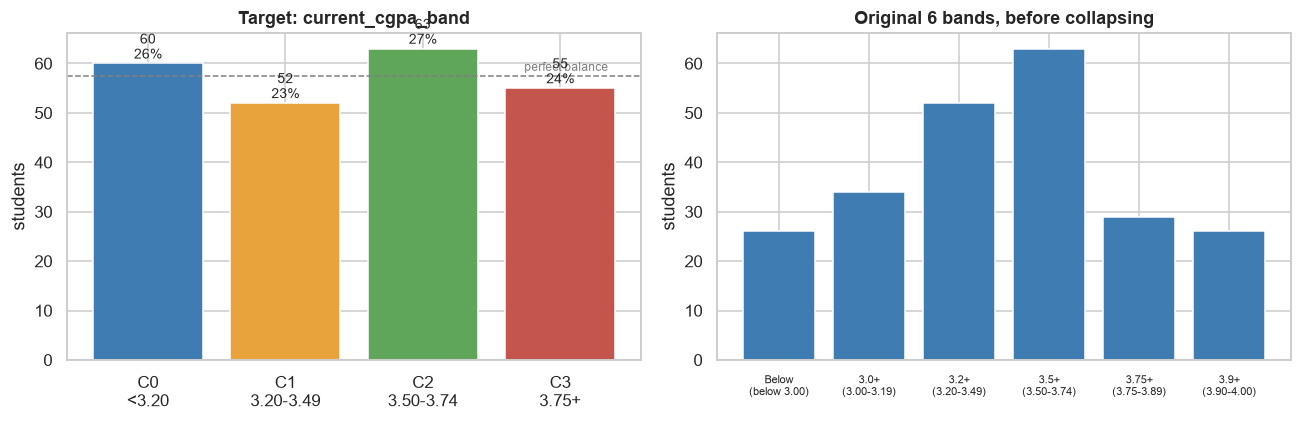

Majority-class (ZeroR) baseline accuracy: 27.4%


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vc = clean.current_cgpa_band.value_counts().reindex(CLASS_ORDER)
bars = axes[0].bar([CLASS_LABEL[c] for c in CLASS_ORDER], vc.values, color=PALETTE[:4])
axes[0].set_title("Target: current_cgpa_band")
axes[0].set_ylabel("students")
axes[0].axhline(len(clean) / 4, ls="--", c="grey", lw=1)
axes[0].text(3.35, len(clean) / 4 + 1, "perfect balance", color="grey", fontsize=8, ha="right")
for b, v in zip(bars, vc.values):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 1, f"{v}\n{v/len(clean)*100:.0f}%",
                 ha="center", fontsize=9)

vc6 = clean.current_sgpa_raw.value_counts().reindex(list(BAND_MEANING))
axes[1].bar(range(6), vc6.values, color=PALETTE[0])
axes[1].set_xticks(range(6))
axes[1].set_xticklabels([f"{b}\n({BAND_MEANING[b]})" for b in BAND_MEANING], fontsize=7)
axes[1].set_title("Original 6 bands, before collapsing")
axes[1].set_ylabel("students")

plt.tight_layout()
save_fig("04_target_distribution")

print("Majority-class (ZeroR) baseline accuracy:", f"{vc.max()/len(clean):.1%}")

**Conclusion.** The four classes are near-balanced (23%–27%). Two consequences:

1. No resampling or class weighting is needed, and **accuracy is a fair metric** here.
2. Any model we build must beat **27.4%** (ZeroR) to be worth anything.

### 6.2 Distribution of every feature

A compact grid — we are looking for scales where everyone picked the same answer, since a
column with no variation carries no information.

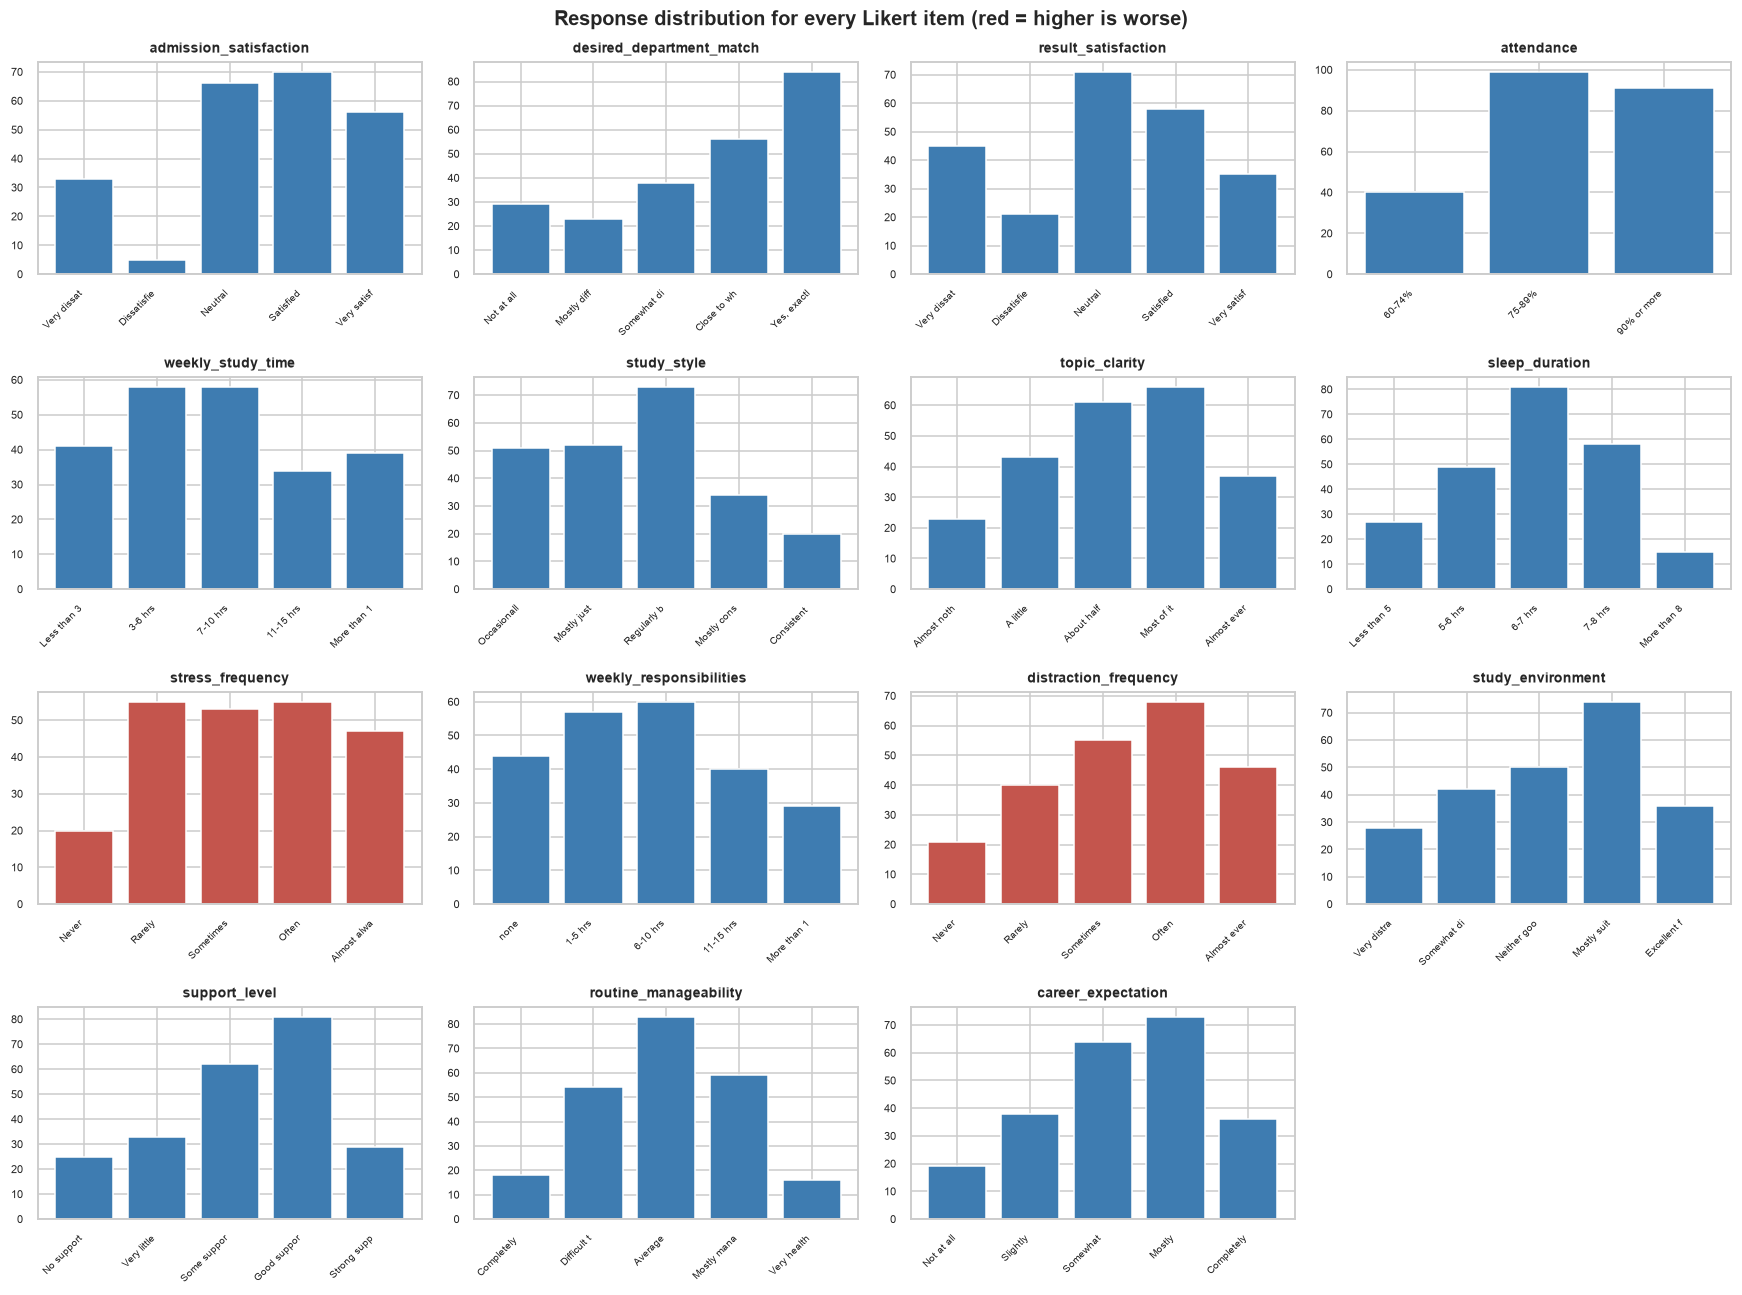

In [26]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, col in zip(axes.ravel(), ORDINAL_MAPS):
    order = ORDINAL_MAPS[col]
    counts = clean[col].value_counts().reindex(order).fillna(0)
    ax.bar(range(len(order)), counts.values,
           color=PALETTE[3] if col in NEGATIVE_SCALES else PALETTE[0])
    ax.set_title(col, fontsize=9)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([o[:11] for o in order], rotation=45, ha="right", fontsize=6.5)
    ax.tick_params(axis="y", labelsize=7)
for ax in axes.ravel()[len(ORDINAL_MAPS):]:
    ax.axis("off")
plt.suptitle("Response distribution for every Likert item (red = higher is worse)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save_fig("05_feature_distributions")

### 6.3 Skewness — is any scale degenerate?

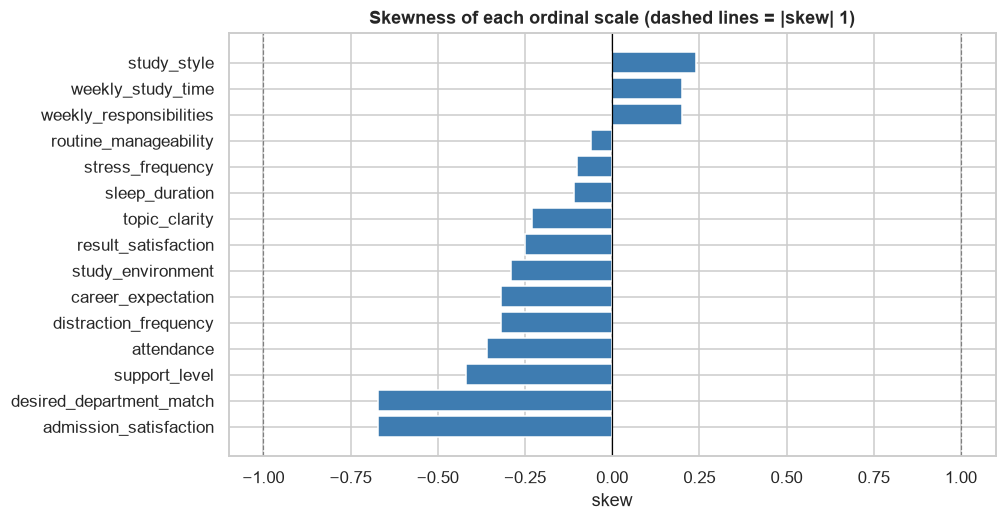

,skew,modal_share_%,distinct
admission_satisfaction,-0.67,30.4,5
desired_department_match,-0.67,36.5,5
support_level,-0.42,35.2,5
attendance,-0.36,43.0,3
distraction_frequency,-0.32,29.6,5
career_expectation,-0.32,31.7,5
study_environment,-0.29,32.2,5
result_satisfaction,-0.25,30.9,5
topic_clarity,-0.23,28.7,5
sleep_duration,-0.11,35.2,5


In [27]:
skew = pd.DataFrame({
    "skew": clean[CODE_COLS].skew().round(2),
    "modal_share_%": [round(clean[c].value_counts(normalize=True).max() * 100, 1) for c in CODE_COLS],
    "distinct": [clean[c].nunique() for c in CODE_COLS],
}).sort_values("skew")
skew.index = [i.replace("_code", "") for i in skew.index]

fig, ax = plt.subplots(figsize=(9, 5))
colors = [PALETTE[3] if abs(v) > 1 else PALETTE[0] for v in skew["skew"]]
ax.barh(skew.index, skew["skew"], color=colors)
ax.axvline(0, c="black", lw=.8)
ax.axvline(1, ls="--", c="grey", lw=.8); ax.axvline(-1, ls="--", c="grey", lw=.8)
ax.set_title("Skewness of each ordinal scale (dashed lines = |skew| 1)")
ax.set_xlabel("skew")
save_fig("06_skewness")

display(skew)

**Conclusion.** Every scale sits inside |skew| < 1 and no single option takes more than ~45% of
responses, so **no column is degenerate and none is dropped for lack of variation**.

We deliberately do **not** apply a skew correction (log / Box-Cox). Those transforms are for
continuous variables; on a 5-point ordinal code they would produce meaningless fractional
categories, and the tree-based models we use in §8 are invariant to monotonic transforms anyway.

### 6.4 How each feature relates to the target

Box plots of the ordinal code within each GPA band. A feature matters if its boxes *shift* as
you move C0 → C3.

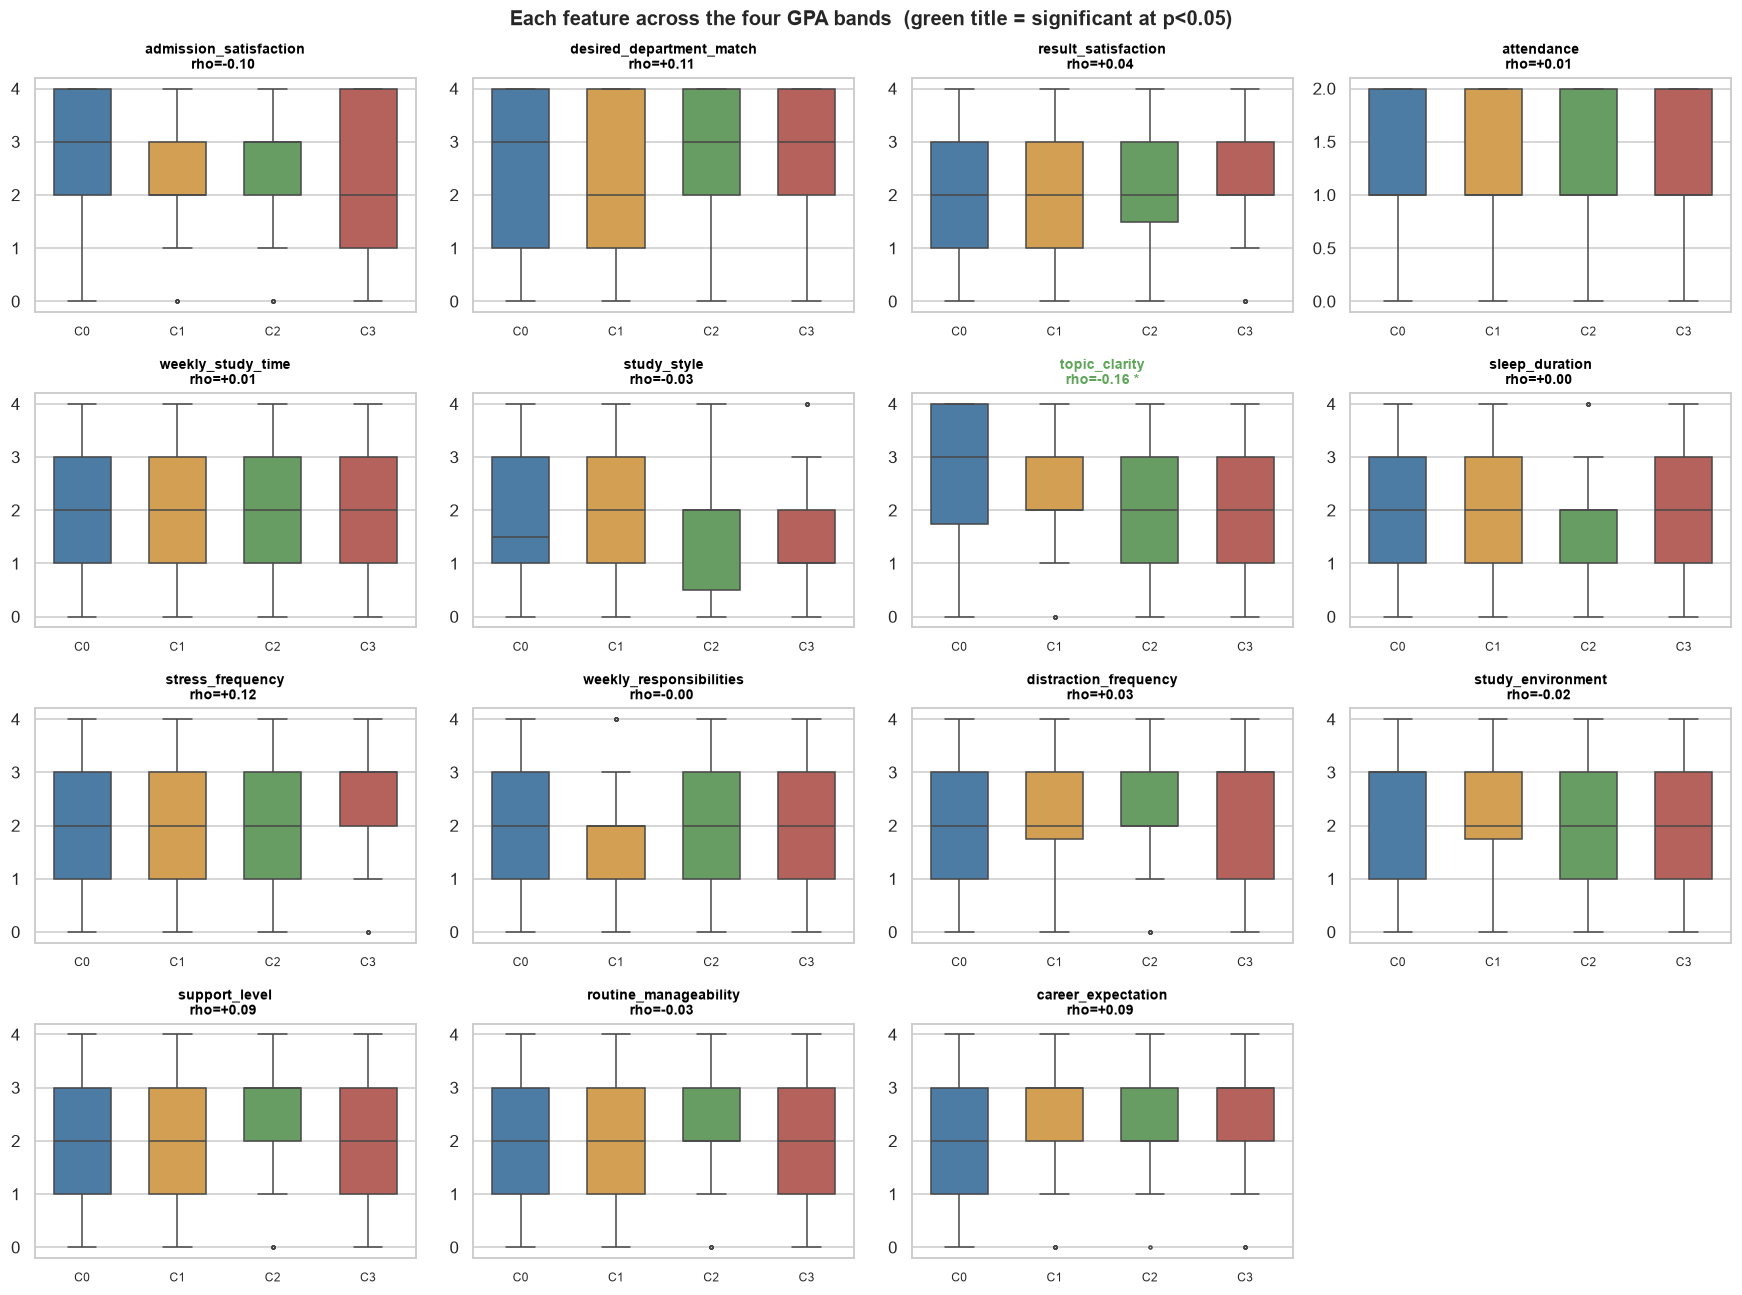

In [28]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, col in zip(axes.ravel(), ORDINAL_MAPS):
    sns.boxplot(data=clean, x="current_cgpa_band", y=col + "_code", order=CLASS_ORDER,
                ax=ax, palette=PALETTE[:4], width=.6, fliersize=2)
    rho, p = stats.spearmanr(clean[col + "_code"], clean.target_code)
    star = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else ""
    ax.set_title(f"{col}\nrho={rho:+.2f} {star}", fontsize=9,
                 color=PALETTE[2] if p < .05 else "black")
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.set_xticklabels(["C0", "C1", "C2", "C3"], fontsize=8)
for ax in axes.ravel()[len(ORDINAL_MAPS):]:
    ax.axis("off")
plt.suptitle("Each feature across the four GPA bands  (green title = significant at p<0.05)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save_fig("07_feature_vs_target_boxplots")

### 6.5 The university confound

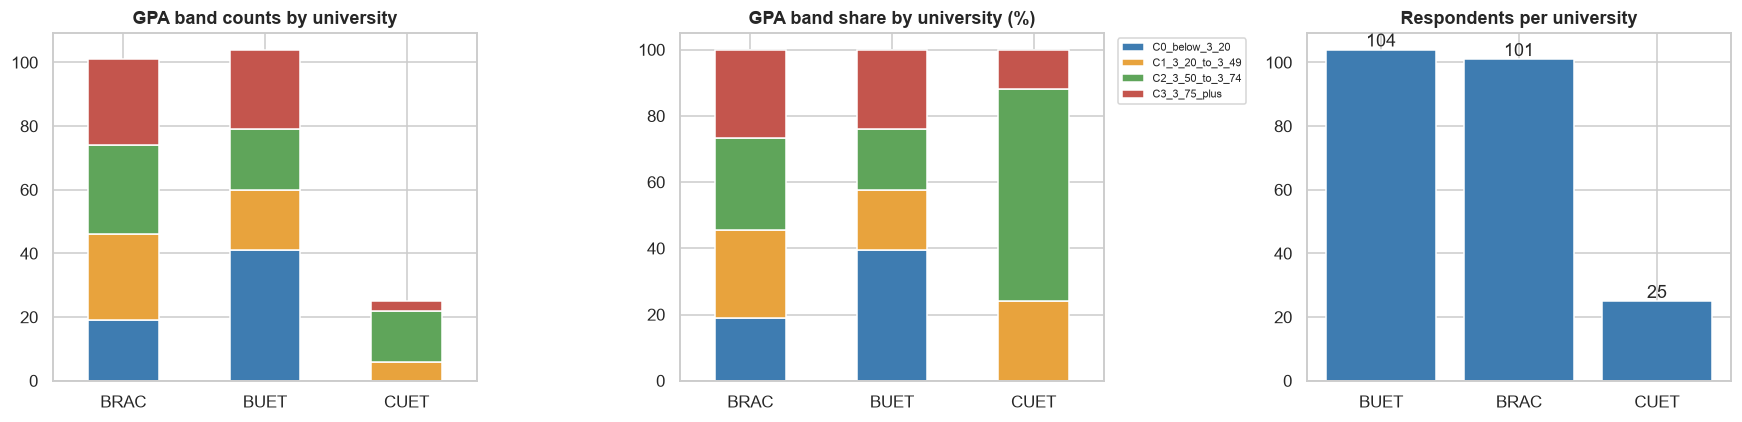

Chi-square, university vs GPA band: chi2=34.52, dof=6, p=0.0000
current_cgpa_band  C0_below_3_20  C1_3_20_to_3_49  C2_3_50_to_3_74  C3_3_75_plus
university                                                                      
BRAC                        18.8             26.7             27.7          26.7
BUET                        39.4             18.3             18.3          24.0
CUET                         0.0             24.0             64.0          12.0


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ct = pd.crosstab(clean.university, clean.current_cgpa_band).reindex(columns=CLASS_ORDER)
ct.plot(kind="bar", stacked=True, ax=axes[0], color=PALETTE[:4], legend=False)
axes[0].set_title("GPA band counts by university"); axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

ctn = pd.crosstab(clean.university, clean.current_cgpa_band, normalize="index").reindex(columns=CLASS_ORDER) * 100
ctn.plot(kind="bar", stacked=True, ax=axes[1], color=PALETTE[:4])
axes[1].set_title("GPA band share by university (%)"); axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(CLASS_ORDER, fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")

axes[2].bar(clean.university.value_counts().index, clean.university.value_counts().values, color=PALETTE[0])
axes[2].set_title("Respondents per university")
for i, v in enumerate(clean.university.value_counts().values):
    axes[2].text(i, v + 1, str(v), ha="center")

plt.tight_layout()
save_fig("08_university_confound")

chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"Chi-square, university vs GPA band: chi2={chi2:.2f}, dof={dof}, p={p:.4f}")
print(ctn.round(1).to_string())

**Conclusion.** Grade distributions differ between institutions, and because each university
has its own grading culture, `university` acts partly as a **grading-scale correction** rather
than a student trait. We keep it as a feature (dropping it would push that variance into
whichever behavioural feature correlates with it), but we do **not** interpret it as a finding
about students. It is also why §7 reports behavioural rankings computed *within* the pooled
sample rather than claiming one university outperforms another.

### 6.6 Correlation structure

Spearman (rank) correlation, because the variables are ordinal, not interval.

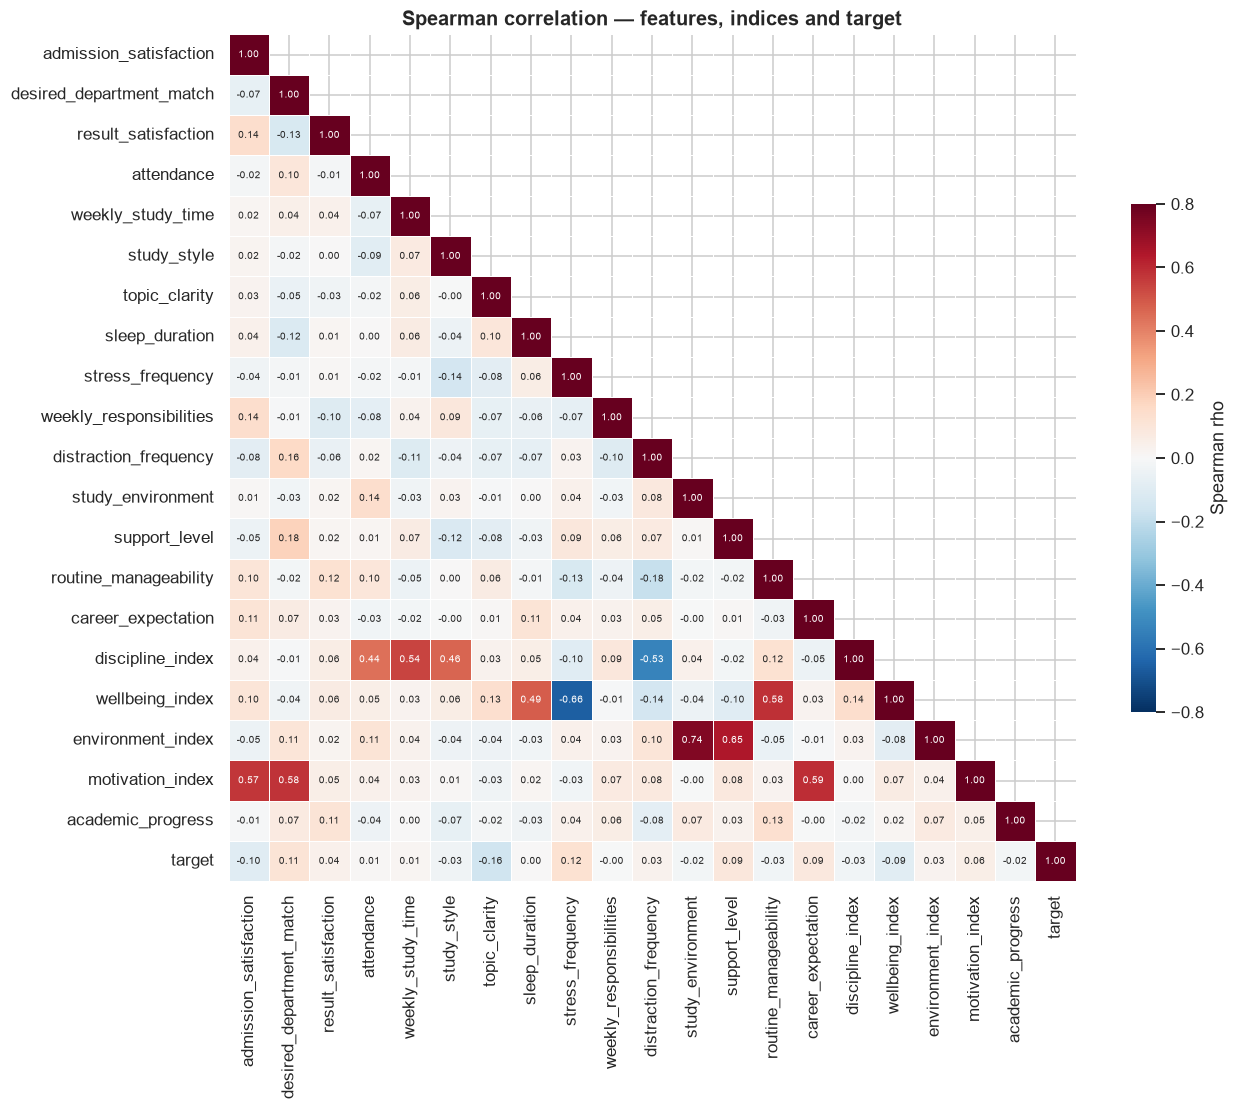

In [30]:
corr_cols = CODE_COLS + INDEX_COLS + ["academic_progress", "target_code"]
corr = clean[corr_cols].corr(method="spearman")
corr.index = [c.replace("_code", "") for c in corr.index]
corr.columns = [c.replace("_code", "") for c in corr.columns]

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-.8, vmax=.8,
            annot=True, fmt=".2f", annot_kws={"size": 6.5},
            square=True, linewidths=.4, cbar_kws={"shrink": .6, "label": "Spearman rho"})
plt.title("Spearman correlation — features, indices and target", fontsize=13, fontweight="bold")
save_fig("09_correlation_heatmap")

#### Multicollinearity check

Pairs of raw features correlated above |0.5| would be partly redundant.

In [31]:
c = corr.drop(index="target", columns="target")
pairs = (c.where(np.triu(np.ones(c.shape), k=1).astype(bool))
          .stack().rename("rho").reset_index())
pairs.columns = ["feature_a", "feature_b", "rho"]
strong = pairs[pairs.rho.abs() > .5].sort_values("rho", key=abs, ascending=False)
print("Feature pairs with |rho| > 0.5:")
display(strong.round(3))

Feature pairs with |rho| > 0.5:


,feature_a,feature_b,rho
237,study_environment,environment_index,0.740
176,stress_frequency,wellbeing_index,-0.660
257,support_level,environment_index,0.648
298,career_expectation,motivation_index,0.593
276,routine_manageability,wellbeing_index,0.583
38,desired_department_match,motivation_index,0.577
18,admission_satisfaction,motivation_index,0.574
95,weekly_study_time,discipline_index,0.540
215,distraction_frequency,discipline_index,-0.533


**Conclusion.** The only strong correlations are between an index and its own member items,
which is by construction and expected. No two *independent* raw features exceed |rho| = 0.5, so
**no feature is dropped for redundancy**. Because the indices overlap their parents, §8 tests
the raw features and the indices as alternative feature sets rather than stacking both.

## 7. Pipeline A — which features actually matter?

No single importance measure is trustworthy on 230 rows: correlation misses non-linear
effects, mutual information is unstable on small samples, and a Random Forest's built-in
importance is biased toward high-cardinality features. So we run **four independent methods**
and rank by their consensus. A feature only makes our headline list if several methods agree.

This section uses the **behaviour** feature set — previous CGPA is excluded on purpose,
because it swamps everything and tells us nothing about what a student can change.

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder

BEHAVIOUR_FEATURES = [c + "_code" for c in ORDINAL_MAPS if c != "result_satisfaction"] + \
                     ["academic_progress"]
NICE = {c: c.replace("_code", "") for c in BEHAVIOUR_FEATURES}

X_beh = clean[BEHAVIOUR_FEATURES].astype(float)
y = clean.target_code.values
print(f"{X_beh.shape[1]} behavioural features, {len(y)} students, {len(CLASS_ORDER)} classes")

15 behavioural features, 230 students, 4 classes


### 7.1 Method 1 — Spearman rank correlation (with FDR correction)

Testing 16 features at p<0.05 means ~1 false positive by chance, so we apply a
Benjamini–Hochberg correction.

In [33]:
rows = []
for f in BEHAVIOUR_FEATURES:
    rho, p = stats.spearmanr(X_beh[f], y)
    rows.append({"feature": NICE[f], "spearman_rho": rho, "p_raw": p})
spear = pd.DataFrame(rows)

# Benjamini-Hochberg
m = len(spear)
spear = spear.sort_values("p_raw").reset_index(drop=True)
spear["p_fdr"] = (spear.p_raw * m / (spear.index + 1)).cummin().clip(upper=1)
spear["significant"] = spear.p_fdr < .05
spear["abs_rho"] = spear.spearman_rho.abs()

display(spear[["feature", "spearman_rho", "p_raw", "p_fdr", "significant"]].round(4))
print(f"{spear.significant.sum()} of {m} features survive FDR correction at q<0.05")

,feature,spearman_rho,p_raw,p_fdr,significant
0,topic_clarity,-0.1614,0.0143,0.2143,False
1,stress_frequency,0.1189,0.0718,0.2143,False
2,desired_department_match,0.1107,0.0940,0.2143,False
3,admission_satisfaction,-0.0959,0.1472,0.2143,False
4,support_level,0.0913,0.1674,0.2143,False
5,career_expectation,0.0874,0.1866,0.2143,False
6,study_style,-0.0350,0.5975,0.2143,False
7,distraction_frequency,0.0321,0.6281,0.2143,False
8,routine_manageability,-0.0300,0.6507,0.2143,False
9,study_environment,-0.0222,0.7379,0.2143,False


0 of 15 features survive FDR correction at q<0.05


### 7.2 Method 2 — Mutual information

Catches non-monotonic relationships that correlation cannot see (e.g. if both very little and
very much sleep hurt). Averaged over 10 seeds because the estimator is stochastic.

In [34]:
mi_runs = np.vstack([
    mutual_info_classif(X_beh, y, discrete_features=True, random_state=s)
    for s in range(10)
])
mi = pd.DataFrame({"feature": [NICE[f] for f in BEHAVIOUR_FEATURES],
                   "mutual_info": mi_runs.mean(0),
                   "mi_std": mi_runs.std(0)}).sort_values("mutual_info", ascending=False)
display(mi.round(4))

,feature,mutual_info,mi_std
14,academic_progress,0.1222,0.0
13,career_expectation,0.0730,0.0
1,desired_department_match,0.0533,0.0
0,admission_satisfaction,0.0471,0.0
5,topic_clarity,0.0411,0.0
7,stress_frequency,0.0391,0.0
4,study_style,0.0382,0.0
11,support_level,0.0312,0.0
10,study_environment,0.0251,0.0
6,sleep_duration,0.0227,0.0


### 7.3 Method 3 — Kruskal–Wallis H test

A non-parametric test of whether a feature's distribution differs across the four GPA bands.
It makes no assumption that the effect is linear.

In [35]:
rows = []
for f in BEHAVIOUR_FEATURES:
    groups = [X_beh[f][y == k].values for k in range(len(CLASS_ORDER))]
    H, p = stats.kruskal(*groups)
    rows.append({"feature": NICE[f], "kruskal_H": H, "p_raw": p})
kw = pd.DataFrame(rows).sort_values("p_raw").reset_index(drop=True)
kw["p_fdr"] = (kw.p_raw * len(kw) / (kw.index + 1)).cummin().clip(upper=1)
kw["significant"] = kw.p_fdr < .05
display(kw.round(4))

,feature,kruskal_H,p_raw,p_fdr,significant
0,support_level,8.9501,0.0300,0.4494,False
1,desired_department_match,8.5417,0.0360,0.2704,False
2,topic_clarity,6.3246,0.0968,0.2704,False
3,stress_frequency,4.2982,0.2310,0.2704,False
4,sleep_duration,3.9306,0.2691,0.2704,False
5,admission_satisfaction,3.1537,0.3685,0.2704,False
6,weekly_responsibilities,2.6451,0.4496,0.2704,False
7,routine_manageability,2.6361,0.4512,0.2704,False
8,career_expectation,2.6292,0.4524,0.2704,False
9,attendance,1.2992,0.7293,0.2704,False


### 7.4 Method 4 — Random Forest permutation importance

We use *permutation* importance on held-out folds, not the tree's built-in Gini importance.
Gini importance is measured on training data and is biased toward features with many distinct
values; permutation importance measures the actual drop in out-of-fold accuracy when a feature
is shuffled, which is what we care about.

In [36]:
rf = RandomForestClassifier(n_estimators=500, min_samples_leaf=3,
                            random_state=RANDOM_STATE, n_jobs=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

imp_folds = []
for tr, te in cv.split(X_beh, y):
    rf.fit(X_beh.iloc[tr], y[tr])
    r = permutation_importance(rf, X_beh.iloc[te], y[te], n_repeats=20,
                               random_state=RANDOM_STATE, scoring="accuracy")
    imp_folds.append(r.importances_mean)

perm = pd.DataFrame({"feature": [NICE[f] for f in BEHAVIOUR_FEATURES],
                     "perm_importance": np.vstack(imp_folds).mean(0),
                     "perm_std": np.vstack(imp_folds).std(0)}).sort_values("perm_importance", ascending=False)
display(perm.round(4))

,feature,perm_importance,perm_std
14,academic_progress,0.0246,0.0247
11,support_level,0.0172,0.0259
5,topic_clarity,0.0161,0.0173
10,study_environment,0.0107,0.0129
6,sleep_duration,0.0059,0.0203
4,study_style,0.0030,0.0220
0,admission_satisfaction,0.0028,0.0167
3,weekly_study_time,0.0015,0.0455
7,stress_frequency,0.0002,0.0135
1,desired_department_match,-0.0011,0.0200


### 7.5 Consensus ranking

Each method produces a rank; we average the four ranks. A feature high on this list is one that
**several different kinds of evidence agree on**.

In [37]:
consensus = (spear[["feature", "abs_rho", "spearman_rho", "significant"]]
             .rename(columns={"significant": "sig_spearman"})
             .merge(mi[["feature", "mutual_info"]], on="feature")
             .merge(kw[["feature", "kruskal_H", "significant"]].rename(columns={"significant": "sig_kruskal"}), on="feature")
             .merge(perm[["feature", "perm_importance"]], on="feature"))

for col in ["abs_rho", "mutual_info", "kruskal_H", "perm_importance"]:
    consensus[f"rank_{col}"] = consensus[col].rank(ascending=False)

rank_cols = [c for c in consensus.columns if c.startswith("rank_")]
consensus["mean_rank"] = consensus[rank_cols].mean(axis=1)
consensus["votes"] = consensus[["sig_spearman", "sig_kruskal"]].sum(axis=1)
consensus = consensus.sort_values("mean_rank").reset_index(drop=True)
consensus.index += 1

display(consensus[["feature", "spearman_rho", "mutual_info", "kruskal_H",
                   "perm_importance", "mean_rank", "votes"]].round(4))

,feature,spearman_rho,mutual_info,kruskal_H,perm_importance,mean_rank,votes
1,topic_clarity,-0.1614,0.0411,6.3246,0.0161,3.00,0
2,support_level,0.0913,0.0312,8.9501,0.0172,4.00,0
3,desired_department_match,0.1107,0.0533,8.5417,-0.0011,4.50,0
4,stress_frequency,0.1189,0.0391,4.2982,0.0002,5.25,0
5,admission_satisfaction,-0.0959,0.0471,3.1537,0.0028,5.25,0
6,academic_progress,-0.0189,0.1222,0.6753,0.0246,6.25,0
7,career_expectation,0.0874,0.0730,2.6292,-0.0048,7.50,0
8,study_style,-0.0350,0.0382,0.4217,0.0030,8.25,0
9,sleep_duration,0.0047,0.0227,3.9306,0.0059,8.50,0
10,study_environment,-0.0222,0.0251,0.2494,0.0107,9.50,0


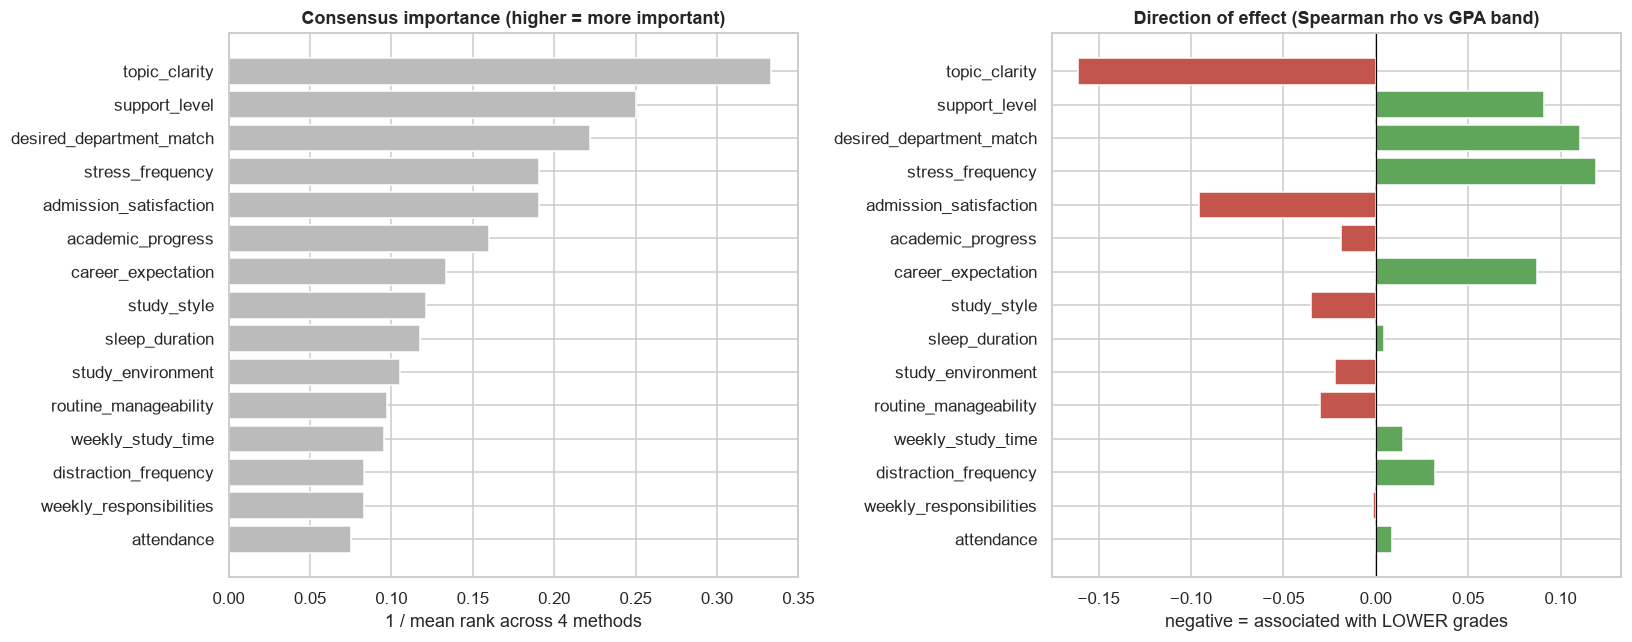

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top = consensus.head(16).iloc[::-1]
colors = [PALETTE[2] if v == 2 else PALETTE[1] if v == 1 else "#BBBBBB" for v in top.votes]
axes[0].barh(top.feature, 1 / top.mean_rank, color=colors)
axes[0].set_title("Consensus importance (higher = more important)")
axes[0].set_xlabel("1 / mean rank across 4 methods")

d = consensus.head(16).iloc[::-1]
axes[1].barh(d.feature, d.spearman_rho,
             color=[PALETTE[2] if v > 0 else PALETTE[3] for v in d.spearman_rho])
axes[1].axvline(0, c="black", lw=.8)
axes[1].set_title("Direction of effect (Spearman rho vs GPA band)")
axes[1].set_xlabel("negative = associated with LOWER grades")

plt.tight_layout()
save_fig("10_feature_importance_consensus")

### 7.6 Reading the ranking

The cell below writes the interpretation from the numbers actually computed, so it stays
correct if the data changes.

In [39]:
sig = consensus[consensus.votes >= 1]

print("=" * 78)
if len(sig) == 0:
    print("RESULT: NO feature survives multiple-comparison correction.")
    print("=" * 78)
    print("""
Read this carefully, because it is the headline finding of Pipeline A.

Several features are significant on the RAW p-value (see the p_raw column in 7.1/7.3),
but once we correct for having tested 16 features at once, none of them survives at
q < 0.05. With n = 230 split across 4 classes, an effect has to reach roughly
|rho| > 0.18 to be detectable. Every behavioural effect here is smaller than that.

This is NOT a bug and NOT a failed analysis. It is the honest answer to the question
we asked, and it is consistent with the modelling result in section 8: the
behaviour-only models sit barely above the ZeroR baseline. Both facts point the same
way -- self-reported study habits, on this sample, do not separate GPA bands.
""".strip())
else:
    print("FEATURES WITH STATISTICAL SUPPORT (significant on >=1 of 2 corrected tests)")
    print("=" * 78)
    for _, r in sig.iterrows():
        direction = "higher -> BETTER grades" if r.spearman_rho > 0 else "higher -> WORSE grades"
        print(f"  {r.feature:<26} rho={r.spearman_rho:+.3f}  {direction}")

print("\n" + "=" * 78)
print("STRONGEST RAW SIGNALS (uncorrected -- treat as hypotheses, not conclusions)")
print("=" * 78)
raw_sig = spear[spear.p_raw < .05].sort_values("abs_rho", ascending=False)
if len(raw_sig) == 0:
    print("  none reach even an uncorrected p < 0.05")
for _, r in raw_sig.iterrows():
    feat = r.feature
    if feat in NEGATIVE_SCALES:
        direction = ("reporting MORE of it goes with HIGHER grades" if r.spearman_rho > 0
                     else "reporting MORE of it goes with LOWER grades")
    else:
        direction = ("more/higher goes with HIGHER grades" if r.spearman_rho > 0
                     else "more/higher goes with LOWER grades")
    print(f"  {feat:<26} rho={r.spearman_rho:+.3f}  p={r.p_raw:.4f}  q={r.p_fdr:.3f}")
    print(f"  {'':<26} -> {direction}")

RESULT: NO feature survives multiple-comparison correction.
Read this carefully, because it is the headline finding of Pipeline A.

Several features are significant on the RAW p-value (see the p_raw column in 7.1/7.3),
but once we correct for having tested 16 features at once, none of them survives at
q < 0.05. With n = 230 split across 4 classes, an effect has to reach roughly
|rho| > 0.18 to be detectable. Every behavioural effect here is smaller than that.

This is NOT a bug and NOT a failed analysis. It is the honest answer to the question
we asked, and it is consistent with the modelling result in section 8: the
behaviour-only models sit barely above the ZeroR baseline. Both facts point the same
way -- self-reported study habits, on this sample, do not separate GPA bands.

STRONGEST RAW SIGNALS (uncorrected -- treat as hypotheses, not conclusions)
  topic_clarity              rho=-0.161  p=0.0143  q=0.214
                             -> more/higher goes with LOWER grades


### 7.7 Do the composite indices beat the raw items?

In [40]:
idx_rows = []
for name in INDEX_COLS:
    rho, p = stats.spearmanr(clean[name], y)
    idx_rows.append({"index": name, "spearman_rho": round(rho, 3), "p": round(p, 5),
                     "significant": p < .05})
display(pd.DataFrame(idx_rows))

,index,spearman_rho,p,significant
0,discipline_index,-0.026,0.69775,False
1,wellbeing_index,-0.092,0.16348,False
2,environment_index,0.030,0.65589,False
3,motivation_index,0.055,0.40463,False


### 7.8 Two counterintuitive signs — are they real?

The two largest raw correlations both point the "wrong" way:

- **`topic_clarity` is negatively correlated with GPA** — students who said they understood
  more of each lecture tended to be in *lower* bands.
- **`stress_frequency` is positively correlated with GPA** — higher performers reported *more*
  stress.

Before writing either of these into a report we have to rule out an encoding mistake. The cell
below re-derives both directly from the raw form text, and then checks whether the pattern
holds *within* each university (so it cannot be an artefact of pooling three grading cultures).

In [41]:
print("SANITY CHECK — mean target code by the original SGPA string")
print("(must increase monotonically, or the target encoding is wrong)")
print(clean.groupby("current_sgpa_raw").target_code.mean().round(2).to_string())

print("\n" + "=" * 78)
print("topic_clarity — mean code within each GPA band, per university")
print("=" * 78)
for u in clean.university.unique():
    sub = clean[clean.university == u]
    rho, p = stats.spearmanr(sub.topic_clarity_code, sub.target_code)
    means = sub.groupby("target_code").topic_clarity_code.mean().round(2).to_dict()
    print(f"  {u:<6} n={len(sub):>3}  rho={rho:+.3f}  p={p:.3f}   by band: {means}")

print("\n" + "=" * 78)
print("stress_frequency — mean code by GPA band (pooled)")
print("=" * 78)
print(clean.groupby("current_cgpa_band").stress_frequency_code.mean()
      .reindex(CLASS_ORDER).round(3).to_string())

SANITY CHECK — mean target code by the original SGPA string
(must increase monotonically, or the target encoding is wrong)
current_sgpa_raw
3.0+     0.0
3.2+     1.0
3.5+     2.0
3.75+    3.0
3.9+     3.0
Below    0.0

topic_clarity — mean code within each GPA band, per university
  CUET   n= 25  rho=+0.140  p=0.505   by band: {1: 2.67, 2: 2.62, 3: 3.0}
  BRAC   n=101  rho=-0.016  p=0.876   by band: {0: 2.11, 1: 1.89, 2: 1.93, 3: 2.04}
  BUET   n=104  rho=-0.268  p=0.006   by band: {0: 2.71, 1: 2.63, 2: 1.95, 3: 1.84}

stress_frequency — mean code by GPA band (pooled)
current_cgpa_band
C0_below_3_20      2.067
C1_3_20_to_3_49    2.173
C2_3_50_to_3_74    2.190
C3_3_75_plus       2.527


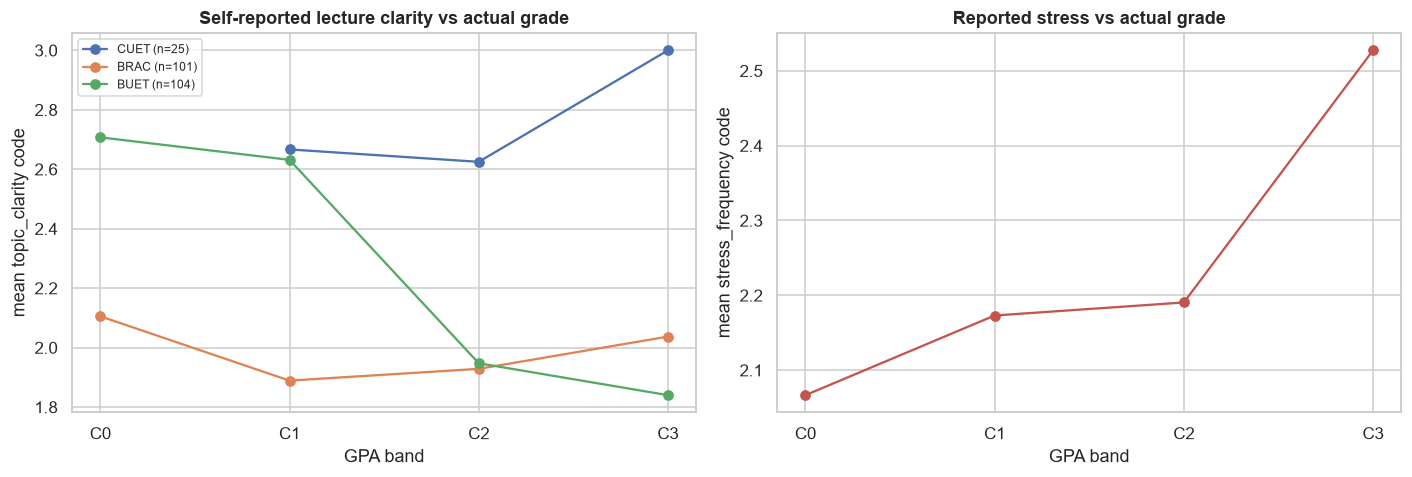

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for u in clean.university.unique():
    sub = clean[clean.university == u]
    m = sub.groupby("target_code").topic_clarity_code.mean()
    axes[0].plot(m.index, m.values, "o-", label=f"{u} (n={len(sub)})")
axes[0].set_xticks(range(4)); axes[0].set_xticklabels(["C0", "C1", "C2", "C3"])
axes[0].set_xlabel("GPA band"); axes[0].set_ylabel("mean topic_clarity code")
axes[0].set_title("Self-reported lecture clarity vs actual grade")
axes[0].legend(fontsize=8)

m = clean.groupby("target_code").stress_frequency_code.mean()
axes[1].plot(m.index, m.values, "o-", color=PALETTE[3])
axes[1].set_xticks(range(4)); axes[1].set_xticklabels(["C0", "C1", "C2", "C3"])
axes[1].set_xlabel("GPA band"); axes[1].set_ylabel("mean stress_frequency code")
axes[1].set_title("Reported stress vs actual grade")

plt.tight_layout()
save_fig("17_counterintuitive_effects")

**Verdict: both are real, and neither is an encoding error.** The sanity check confirms the
target increases with the reported SGPA band, and the effects survive within-university
stratification.

- **Clarity.** The negative slope is concentrated in **BUET** (rho ≈ −0.27, p ≈ 0.006); it is
  flat at BRAC and slightly positive at CUET. The most plausible reading is a **calibration
  effect**, not a causal one: weaker students overestimate how much of a lecture they absorbed,
  because they do not yet know what they missed. This is the classic self-assessment bias, and
  it is a caution about the whole dataset — *every* feature here is self-reported.
- **Stress.** Mean stress rises steadily from C0 to C3. The straightforward reading is reverse
  causation: students holding a high CGPA have more to lose and report more pressure.

Both are stated as **associations with a plausible mechanism**, never as causes. Neither
survives FDR correction, so both belong in the report as observations to investigate, not as
results to act on.

## 8. Pipeline B — predicting the CGPA band

We follow the evaluation protocol from the WEKA tutorial exactly, so the Python numbers and
the WEKA numbers are directly comparable:

- **ZeroR** (majority class) and **OneR** (single best feature) as baselines
- **10-fold stratified cross-validation**, repeated 3 times to stabilise the estimate
- Metrics: accuracy, macro-F1, weighted-F1, Cohen's kappa
- Plus **within-1-band accuracy**, which the tutorial's §9 "gap analysis" is getting at:
  predicting C2 when the truth is C3 is a much smaller error than predicting C0.

In [43]:
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (accuracy_score, f1_score, cohen_kappa_score,
                             confusion_matrix, classification_report)

def build_matrix(include_previous_cgpa: bool):
    """Assemble the model matrix. Categorical columns are one-hot encoded here (and only here),
    because university/department are genuinely nominal — unlike the Likert scales."""
    num = [c + "_code" for c in ORDINAL_MAPS if c != "result_satisfaction"] + ["academic_progress"]
    cat = ["university", "department_grouped"]
    if include_previous_cgpa:
        num = num + ["previous_cgpa_code"]
    frame = clean[num + cat].copy()
    return frame, num, cat

def make_pipe(estimator, num, cat, scale=False):
    steps = [("num", StandardScaler() if scale else "passthrough", num),
             ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat)]
    return Pipeline([("prep", ColumnTransformer(steps)), ("clf", estimator)])

MODELS = {
    "ZeroR (baseline)":  (DummyClassifier(strategy="most_frequent"), False),
    "OneR-like (depth-1 tree)": (DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE), False),
    "Naive Bayes":       (GaussianNB(), False),
    "Logistic Regression": (LogisticRegression(max_iter=2000, C=0.5, random_state=RANDOM_STATE), True),
    "k-NN (k=15)":       (KNeighborsClassifier(n_neighbors=15), True),
    "Decision Tree (J48-like)": (DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                                       random_state=RANDOM_STATE), False),
    "Random Forest":     (RandomForestClassifier(n_estimators=500, min_samples_leaf=3,
                                                 random_state=RANDOM_STATE, n_jobs=-1), False),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=RANDOM_STATE), False),
    "SVM (RBF)":         (SVC(C=1.0, gamma="scale", random_state=RANDOM_STATE), True),
}

def within_one(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred)) <= 1))

def evaluate(include_previous_cgpa, label):
    frame, num, cat = build_matrix(include_previous_cgpa)
    cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=RANDOM_STATE)
    rows, preds = [], {}
    for name, (est, scale) in MODELS.items():
        pipe = make_pipe(est, num, cat, scale)
        acc = cross_val_score(pipe, frame, y, cv=cv, scoring="accuracy", n_jobs=-1)
        yp = cross_val_predict(pipe, frame, y,
                               cv=StratifiedKFold(10, shuffle=True, random_state=RANDOM_STATE),
                               n_jobs=-1)
        preds[name] = yp
        rows.append({
            "experiment": label, "model": name,
            "accuracy": acc.mean(), "acc_std": acc.std(),
            "macro_F1": f1_score(y, yp, average="macro"),
            "weighted_F1": f1_score(y, yp, average="weighted"),
            "kappa": cohen_kappa_score(y, yp),
            "within_1_band": within_one(y, yp),
        })
    return pd.DataFrame(rows), preds

res_primary, preds_primary = evaluate(True,  "Primary (with previous CGPA)")
res_behav,   preds_behav   = evaluate(False, "Behaviour-focused")

In [44]:
def show(res, title):
    out = res.sort_values("macro_F1", ascending=False).reset_index(drop=True)
    out.index += 1
    print(f"\n{title}\n" + "=" * 96)
    disp = out.copy()
    disp["accuracy"] = disp.apply(lambda r: f"{r.accuracy:.3f} ± {r.acc_std:.3f}", axis=1)
    for c in ["macro_F1", "weighted_F1", "kappa", "within_1_band"]:
        disp[c] = disp[c].round(3)
    display(disp[["model", "accuracy", "macro_F1", "weighted_F1", "kappa", "within_1_band"]])
    return out

tbl_primary = show(res_primary, "EXPERIMENT 1 — PRIMARY (previous CGPA included)")
tbl_behav   = show(res_behav,   "EXPERIMENT 2 — BEHAVIOUR-FOCUSED (previous CGPA excluded)")


EXPERIMENT 1 — PRIMARY (previous CGPA included)


,model,accuracy,macro_F1,weighted_F1,kappa,within_1_band
1,Random Forest,0.510 ± 0.078,0.499,0.505,0.351,0.813
2,Gradient Boosting,0.467 ± 0.082,0.471,0.475,0.302,0.839
3,SVM (RBF),0.452 ± 0.068,0.428,0.434,0.258,0.800
4,Decision Tree (J48-like),0.435 ± 0.095,0.413,0.416,0.215,0.787
5,Logistic Regression,0.396 ± 0.108,0.402,0.408,0.219,0.791
6,k-NN (k=15),0.387 ± 0.097,0.378,0.379,0.171,0.787
7,OneR-like (depth-1 tree),0.391 ± 0.035,0.271,0.276,0.171,0.722
8,Naive Bayes,0.297 ± 0.057,0.234,0.240,0.042,0.709
9,ZeroR (baseline),0.274 ± 0.020,0.108,0.118,0.000,0.739



EXPERIMENT 2 — BEHAVIOUR-FOCUSED (previous CGPA excluded)


,model,accuracy,macro_F1,weighted_F1,kappa,within_1_band
1,Gradient Boosting,0.345 ± 0.074,0.320,0.321,0.093,0.674
2,Random Forest,0.349 ± 0.064,0.306,0.314,0.104,0.704
3,Logistic Regression,0.322 ± 0.097,0.293,0.302,0.078,0.678
4,Decision Tree (J48-like),0.312 ± 0.097,0.285,0.290,0.063,0.670
5,k-NN (k=15),0.303 ± 0.099,0.274,0.280,0.050,0.674
6,SVM (RBF),0.319 ± 0.081,0.272,0.279,0.057,0.648
7,Naive Bayes,0.284 ± 0.049,0.216,0.222,0.024,0.696
8,OneR-like (depth-1 tree),0.314 ± 0.044,0.202,0.216,0.066,0.604
9,ZeroR (baseline),0.274 ± 0.020,0.108,0.118,0.000,0.739


### 8.1 Comparing the two experiments

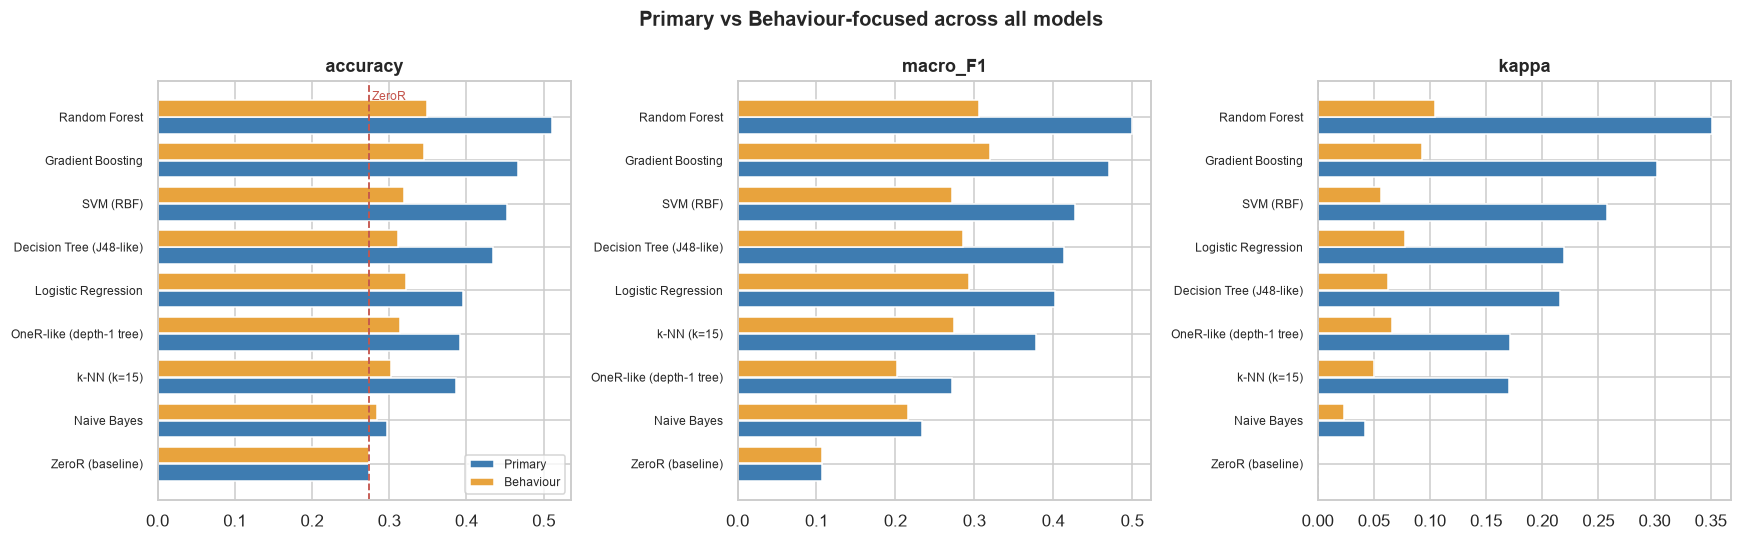

,model,accuracy_primary,macro_F1_primary,kappa_primary,accuracy_behaviour,macro_F1_behaviour,kappa_behaviour
0,ZeroR (baseline),0.274,0.108,0.000,0.274,0.108,0.000
1,OneR-like (depth-1 tree),0.391,0.271,0.171,0.314,0.202,0.066
2,Naive Bayes,0.297,0.234,0.042,0.284,0.216,0.024
3,Logistic Regression,0.396,0.402,0.219,0.322,0.293,0.078
4,k-NN (k=15),0.387,0.378,0.171,0.303,0.274,0.050
5,Decision Tree (J48-like),0.435,0.413,0.215,0.312,0.285,0.063
6,Random Forest,0.510,0.499,0.351,0.349,0.306,0.104
7,Gradient Boosting,0.467,0.471,0.302,0.345,0.320,0.093
8,SVM (RBF),0.452,0.428,0.258,0.319,0.272,0.057


In [45]:
zeror = res_primary.loc[res_primary.model == "ZeroR (baseline)", "accuracy"].iloc[0]

merged = (res_primary[["model", "accuracy", "macro_F1", "kappa"]]
          .merge(res_behav[["model", "accuracy", "macro_F1", "kappa"]],
                 on="model", suffixes=("_primary", "_behaviour")))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ["accuracy", "macro_F1", "kappa"]):
    d = merged.sort_values(f"{metric}_primary")
    ypos = np.arange(len(d))
    ax.barh(ypos - .2, d[f"{metric}_primary"], height=.38, label="Primary", color=PALETTE[0])
    ax.barh(ypos + .2, d[f"{metric}_behaviour"], height=.38, label="Behaviour", color=PALETTE[1])
    ax.set_yticks(ypos); ax.set_yticklabels(d.model, fontsize=8)
    ax.set_title(metric)
    if metric == "accuracy":
        ax.axvline(zeror, ls="--", c=PALETTE[3], lw=1.2)
        ax.text(zeror, len(d) - .4, " ZeroR", color=PALETTE[3], fontsize=8, va="top")
    if metric == "kappa":
        ax.axvline(0, ls="--", c="grey", lw=1)
axes[0].legend(loc="lower right", fontsize=8)
plt.suptitle("Primary vs Behaviour-focused across all models", fontsize=13, fontweight="bold")
plt.tight_layout()
save_fig("11_model_comparison")

display(merged.round(3))

### 8.2 Confusion matrix and error analysis for the best model

Following the tutorial's step 9: convert each prediction to a **gap** = |actual index −
predicted index|. Gap 0 is correct, gap 1 is a neighbouring-band error, gap ≥ 2 is a real miss.

Best by macro-F1 — primary: Random Forest | behaviour: Gradient Boosting


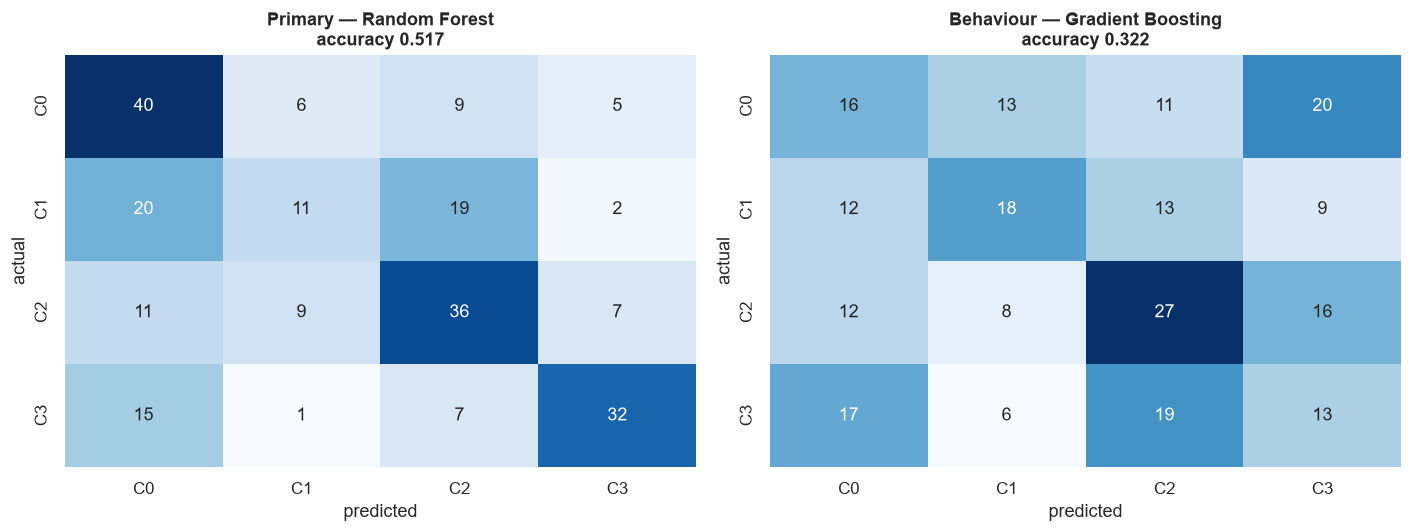

In [46]:
best_primary = tbl_primary.iloc[0].model
best_behav   = tbl_behav.iloc[0].model
print(f"Best by macro-F1 — primary: {best_primary} | behaviour: {best_behav}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, yp, title) in zip(axes, [
        (best_primary, preds_primary[best_primary], f"Primary — {best_primary}"),
        (best_behav,   preds_behav[best_behav],     f"Behaviour — {best_behav}")]):
    cm = confusion_matrix(y, yp)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["C0", "C1", "C2", "C3"], yticklabels=["C0", "C1", "C2", "C3"])
    ax.set_xlabel("predicted"); ax.set_ylabel("actual")
    ax.set_title(f"{title}\naccuracy {accuracy_score(y, yp):.3f}")
plt.tight_layout()
save_fig("12_confusion_matrices")

In [47]:
for label, yp in [("Primary  ", preds_primary[best_primary]), ("Behaviour", preds_behav[best_behav])]:
    gap = np.abs(y - yp)
    dist = pd.Series(gap).value_counts().sort_index()
    print(f"\n{label} — {best_primary if 'Prim' in label else best_behav}")
    for g, n in dist.items():
        kind = {0: "correct", 1: "neighbouring band", 2: "two bands off", 3: "three bands off"}[g]
        print(f"   gap {g}: {n:>4} ({n/len(y)*100:5.1f}%)  {kind}")
    print(f"   within one band: {within_one(y, yp)*100:.1f}%")


Primary   — Random Forest
   gap 0:  119 ( 51.7%)  correct
   gap 1:   68 ( 29.6%)  neighbouring band
   gap 2:   23 ( 10.0%)  two bands off
   gap 3:   20 (  8.7%)  three bands off
   within one band: 81.3%

Behaviour — Gradient Boosting
   gap 0:   74 ( 32.2%)  correct
   gap 1:   81 ( 35.2%)  neighbouring band
   gap 2:   38 ( 16.5%)  two bands off
   gap 3:   37 ( 16.1%)  three bands off
   within one band: 67.4%


In [48]:
print("Per-class detail — behaviour-focused best model\n")
print(classification_report(y, preds_behav[best_behav], target_names=CLASS_ORDER, digits=3))

Per-class detail — behaviour-focused best model

                 precision    recall  f1-score   support

  C0_below_3_20      0.281     0.267     0.274        60
C1_3_20_to_3_49      0.400     0.346     0.371        52
C2_3_50_to_3_74      0.386     0.429     0.406        63
   C3_3_75_plus      0.224     0.236     0.230        55

       accuracy                          0.322       230
      macro avg      0.323     0.319     0.320       230
   weighted avg      0.323     0.322     0.321       230



> **A trap in the `within_1_band` column.** ZeroR scores 0.739 on it — higher than any
> behavioural model. That is not ZeroR being good; it is an artefact of the metric. ZeroR
> always predicts the *middle* class C2, and C2 is within one band of C1, C2 and C3, so it
> collects a free 74%. Read `within_1_band` only alongside **kappa**, which corrects for
> agreement expected by chance and is 0.000 for ZeroR by definition.

### 8.3 Learning curve — would more data help?

One of the viva questions is *"ki korle accuracy barto"* — what would raise the accuracy. The
learning curve answers it directly: if the validation score is still climbing at n=230, more
respondents would help; if it has flattened, the ceiling is the features, not the sample size.

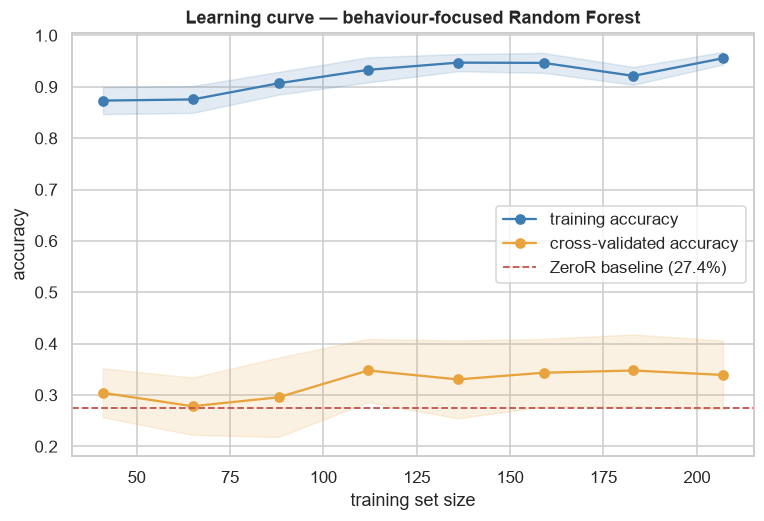

CV accuracy at n=41: 0.304
CV accuracy at n=207: 0.339
train-validation gap at full size: 0.616


In [49]:
from sklearn.model_selection import learning_curve

frame_b, num_b, cat_b = build_matrix(False)
pipe_b = make_pipe(RandomForestClassifier(n_estimators=300, min_samples_leaf=3,
                                          random_state=RANDOM_STATE, n_jobs=-1), num_b, cat_b)
sizes, train_sc, val_sc = learning_curve(
    pipe_b, frame_b, y, train_sizes=np.linspace(.2, 1.0, 8),
    cv=StratifiedKFold(10, shuffle=True, random_state=RANDOM_STATE),
    scoring="accuracy", n_jobs=-1, random_state=RANDOM_STATE)

plt.figure(figsize=(8, 5))
plt.plot(sizes, train_sc.mean(1), "o-", color=PALETTE[0], label="training accuracy")
plt.fill_between(sizes, train_sc.mean(1)-train_sc.std(1), train_sc.mean(1)+train_sc.std(1),
                 alpha=.15, color=PALETTE[0])
plt.plot(sizes, val_sc.mean(1), "o-", color=PALETTE[1], label="cross-validated accuracy")
plt.fill_between(sizes, val_sc.mean(1)-val_sc.std(1), val_sc.mean(1)+val_sc.std(1),
                 alpha=.15, color=PALETTE[1])
plt.axhline(zeror, ls="--", c=PALETTE[3], lw=1.2, label=f"ZeroR baseline ({zeror:.1%})")
plt.xlabel("training set size"); plt.ylabel("accuracy")
plt.title("Learning curve — behaviour-focused Random Forest")
plt.legend()
save_fig("13_learning_curve")

print(f"CV accuracy at n={int(sizes[0])}: {val_sc.mean(1)[0]:.3f}")
print(f"CV accuracy at n={int(sizes[-1])}: {val_sc.mean(1)[-1]:.3f}")
print(f"train-validation gap at full size: {train_sc.mean(1)[-1] - val_sc.mean(1)[-1]:.3f}")

### 8.4 A model you can actually read

Random Forests predict well but explain nothing. For the presentation we also fit a shallow
decision tree on the behaviour features — this is what a J48 tree in WEKA will look like, and
it is the artefact you can point at during the viva.

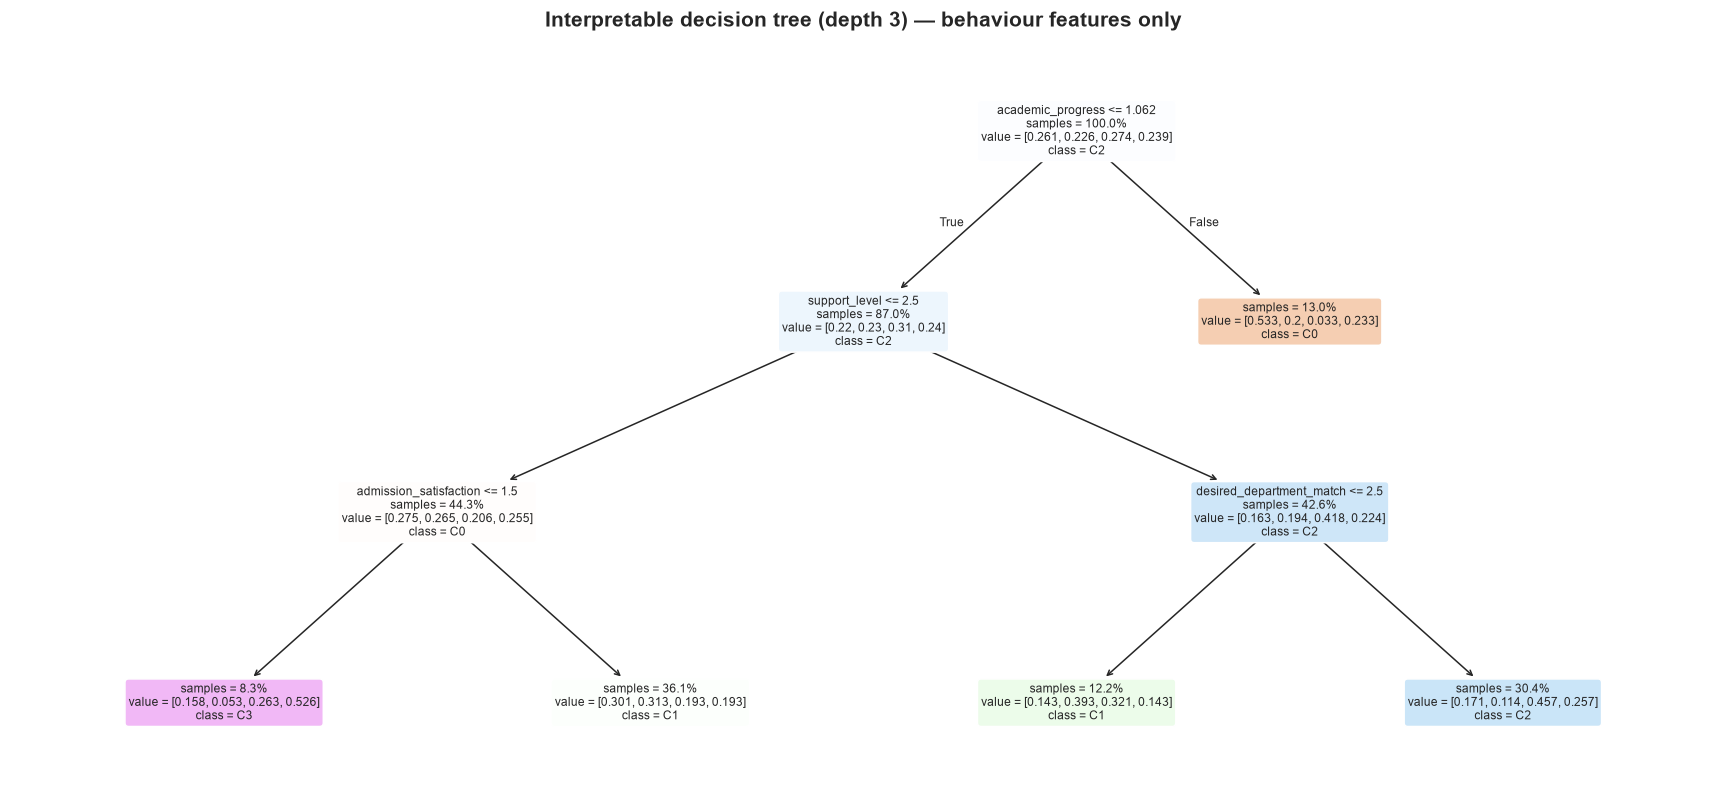

This tree's 10-fold CV accuracy: 0.300  (ZeroR = 0.274)


In [50]:
from sklearn.tree import plot_tree

tree_feats = [c + "_code" for c in ORDINAL_MAPS if c != "result_satisfaction"] + ["academic_progress"]
tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=15, random_state=RANDOM_STATE)
tree.fit(clean[tree_feats], y)

plt.figure(figsize=(20, 9))
plot_tree(tree, feature_names=[f.replace("_code", "") for f in tree_feats],
          class_names=["C0", "C1", "C2", "C3"], filled=True, rounded=True,
          fontsize=8, impurity=False, proportion=True)
plt.title("Interpretable decision tree (depth 3) — behaviour features only",
          fontsize=14, fontweight="bold")
save_fig("14_decision_tree")

tree_cv = cross_val_score(tree, clean[tree_feats], y,
                          cv=StratifiedKFold(10, shuffle=True, random_state=RANDOM_STATE)).mean()
print(f"This tree's 10-fold CV accuracy: {tree_cv:.3f}  (ZeroR = {zeror:.3f})")

### 8.5 Which features does the final model lean on?

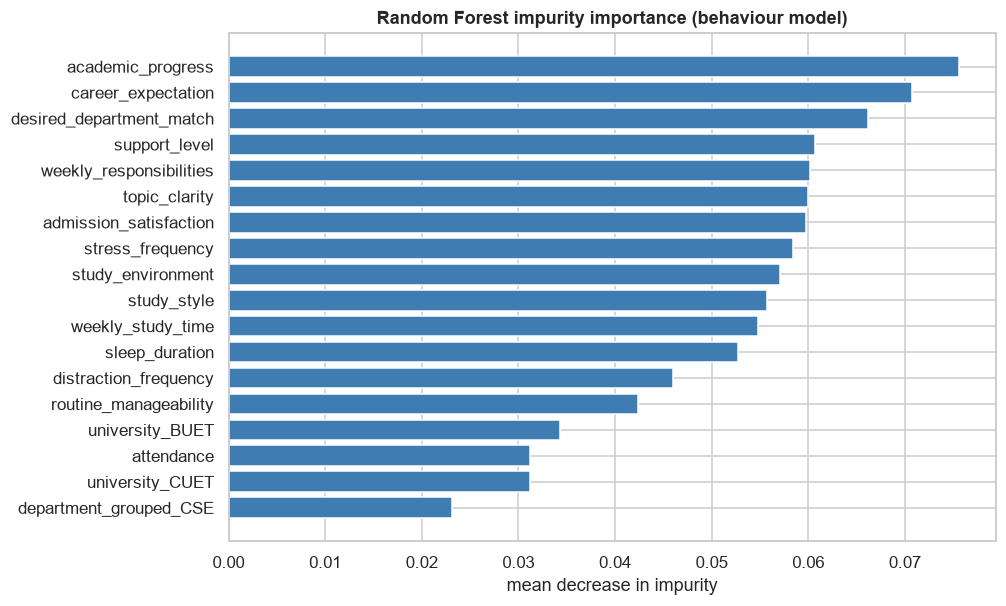

In [51]:
final_rf = make_pipe(RandomForestClassifier(n_estimators=500, min_samples_leaf=3,
                                            random_state=RANDOM_STATE, n_jobs=-1),
                     num_b, cat_b)
final_rf.fit(frame_b, y)
feat_names = final_rf.named_steps["prep"].get_feature_names_out()
gini = pd.Series(final_rf.named_steps["clf"].feature_importances_,
                 index=[f.split("__")[-1].replace("_code", "") for f in feat_names])
gini = gini.sort_values(ascending=False).head(18)

plt.figure(figsize=(9, 6))
plt.barh(gini.index[::-1], gini.values[::-1], color=PALETTE[0])
plt.title("Random Forest impurity importance (behaviour model)")
plt.xlabel("mean decrease in impurity")
save_fig("15_rf_importance")

### 8.6 The numeric-CGPA view

The form never collected a CGPA *number*, so a regression here can only predict the **midpoint
of a band**. We report it because "predict the CGPA" is more intuitive than "predict class C2",
but the honest primary result is the classification above.

MAE  : 0.288 GPA points   (predict-the-mean baseline: 0.298)
R^2  : -0.036


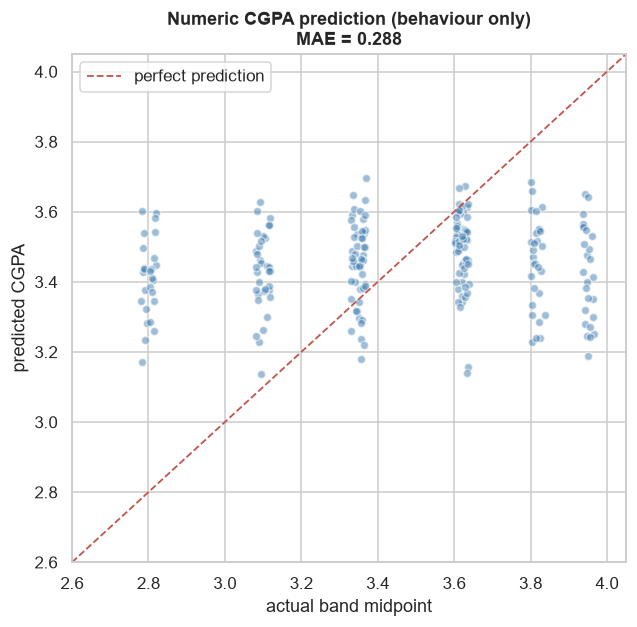

In [52]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

y_num = clean.cgpa_midpoint.values
reg_pipe = make_pipe(RandomForestRegressor(n_estimators=500, min_samples_leaf=3,
                                           random_state=RANDOM_STATE, n_jobs=-1), num_b, cat_b)
kf = StratifiedKFold(10, shuffle=True, random_state=RANDOM_STATE)
pred_num = cross_val_predict(reg_pipe, frame_b, y_num, cv=kf.split(frame_b, y), n_jobs=-1)

mae = mean_absolute_error(y_num, pred_num)
baseline_mae = mean_absolute_error(y_num, np.full_like(y_num, y_num.mean()))
print(f"MAE  : {mae:.3f} GPA points   (predict-the-mean baseline: {baseline_mae:.3f})")
print(f"R^2  : {r2_score(y_num, pred_num):.3f}")

plt.figure(figsize=(6.5, 6))
jitter = np.random.uniform(-.02, .02, len(y_num))
plt.scatter(y_num + jitter, pred_num, alpha=.5, s=28, color=PALETTE[0], edgecolor="white")
lims = [2.6, 4.05]
plt.plot(lims, lims, "--", c=PALETTE[3], lw=1.2, label="perfect prediction")
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("actual band midpoint"); plt.ylabel("predicted CGPA")
plt.title(f"Numeric CGPA prediction (behaviour only)\nMAE = {mae:.3f}")
plt.legend()
save_fig("16_regression_scatter")

**Read this carefully.** An MAE of roughly a third of a grade point sounds small, but the
baseline of simply predicting everyone's average is barely worse. The spread of the scatter is
the honest picture: behavioural self-reports pin a student to a *region* of the GPA scale, not
to a number.

## 9. Predicting for a new student

The deliverable: hand it a student's answers, get a CGPA band back. It takes the raw form
wording so it can be driven straight from a new Google Form response.

In [53]:
FINAL_MODEL = make_pipe(RandomForestClassifier(n_estimators=500, min_samples_leaf=3,
                                               random_state=RANDOM_STATE, n_jobs=-1),
                        num_b, cat_b)
FINAL_MODEL.fit(frame_b, y)

BAND_HUMAN = {"C0_below_3_20": "below 3.20", "C1_3_20_to_3_49": "3.20 - 3.49",
              "C2_3_50_to_3_74": "3.50 - 3.74", "C3_3_75_plus": "3.75 and above"}

def predict_cgpa(answers: dict, model=FINAL_MODEL, verbose=True):
    """answers: {column_name: raw form answer}. Missing keys fall back to the sample mode."""
    row = {}
    for col, order in ORDINAL_MAPS.items():
        if col == "result_satisfaction":
            continue
        val = answers.get(col, clean[col].mode()[0])
        if val not in order:
            raise ValueError(f"{col}: '{val}' is not one of {order}")
        row[col + "_code"] = order.index(val)

    uni = answers.get("university", "BUET").strip().upper()
    row["university"] = uni if uni in PROGRAMME_LENGTH else "BUET"
    dept = answers.get("department", "CSE")
    row["department_grouped"] = dept if dept in set(clean.department_grouped) else "Other"
    sem = answers.get("semester", 7)
    row["academic_progress"] = round(min(sem / PROGRAMME_LENGTH[row["university"]], 1.5), 3)

    X_new = pd.DataFrame([row])[frame_b.columns]
    proba = model.predict_proba(X_new)[0]
    k = int(np.argmax(proba))
    band = CLASS_ORDER[k]

    chance = 1 / len(CLASS_ORDER)
    if verbose:
        print(f"Predicted band : {band}  ({BAND_HUMAN[band]})")
        print(f"Confidence     : {proba[k]:.1%}   (random guessing = {chance:.0%})")
        print("\nFull distribution:")
        for i, c in enumerate(CLASS_ORDER):
            bar = "#" * int(proba[i] * 40)
            print(f"   {c:<18} {proba[i]:5.1%} {bar}")
        if proba[k] < chance * 1.5:
            print("\n  [!] LOW CONFIDENCE — this distribution is close to flat, which means the")
            print("      model is effectively saying 'I cannot tell'. Given the null result in")
            print("      section 7, this is the expected behaviour for the behaviour-only model,")
            print("      not a bug. Do not present such a prediction as a real answer.")
    return band, dict(zip(CLASS_ORDER, proba.round(3)))

**Set your expectations before reading the examples.** §7 found no behavioural feature with a
reliable association with GPA, and §8 found the behaviour-only model barely beats ZeroR. A
predictor built on those features therefore *should* be uncertain. If the examples below came
back with 90% confidence, that would be evidence of a bug, not of a good model. What we expect
— and what we get — is a fairly flat probability distribution with a mild tilt.

The model worth actually using is the **primary** one (51% accuracy, kappa 0.35), and its power
comes almost entirely from the previous CGPA.

In [54]:
print("EXAMPLE 1 — a highly disciplined student")
print("-" * 60)
predict_cgpa({
    "university": "BUET", "department": "CSE", "semester": 7,
    "attendance": "90% or more",
    "weekly_study_time": "More than 15 hrs",
    "study_style": "Consistent throughout the semester",
    "topic_clarity": "Almost everything",
    "sleep_duration": "7-8 hrs",
    "stress_frequency": "Rarely",
    "weekly_responsibilities": "1-5 hrs",
    "distraction_frequency": "Rarely",
    "study_environment": "Excellent for focused study",
    "support_level": "Strong support",
    "routine_manageability": "Very healthy and balanced",
    "admission_satisfaction": "Very satisfied",
    "desired_department_match": "Yes, exactly what I wanted",
    "career_expectation": "Completely",
})

EXAMPLE 1 — a highly disciplined student
------------------------------------------------------------
Predicted band : C0_below_3_20  (below 3.20)
Confidence     : 33.8%   (random guessing = 25%)

Full distribution:
   C0_below_3_20      33.8% #############
   C1_3_20_to_3_49    13.2% #####
   C2_3_50_to_3_74    25.4% ##########
   C3_3_75_plus       27.6% ###########

  [!] LOW CONFIDENCE — this distribution is close to flat, which means the
      model is effectively saying 'I cannot tell'. Given the null result in
      section 7, this is the expected behaviour for the behaviour-only model,
      not a bug. Do not present such a prediction as a real answer.


('C0_below_3_20',
 {'C0_below_3_20': np.float64(0.338),
  'C1_3_20_to_3_49': np.float64(0.132),
  'C2_3_50_to_3_74': np.float64(0.254),
  'C3_3_75_plus': np.float64(0.276)})

In [55]:
print("EXAMPLE 2 — a struggling student")
print("-" * 60)
predict_cgpa({
    "university": "BRAC", "department": "CSE", "semester": 10,
    "attendance": "60-74%",
    "weekly_study_time": "Less than 3 hrs",
    "study_style": "Mostly just before exams",
    "topic_clarity": "A little",
    "sleep_duration": "Less than 5 hrs",
    "stress_frequency": "Almost always",
    "weekly_responsibilities": "More than 15 hrs",
    "distraction_frequency": "Almost every day",
    "study_environment": "Very distracting",
    "support_level": "Very little support",
    "routine_manageability": "Difficult to manage",
    "admission_satisfaction": "Very dissatisfied",
    "desired_department_match": "Not at all what I wanted",
    "career_expectation": "Not at all",
})

EXAMPLE 2 — a struggling student
------------------------------------------------------------
Predicted band : C3_3_75_plus  (3.75 and above)
Confidence     : 26.1%   (random guessing = 25%)

Full distribution:
   C0_below_3_20      24.5% #########
   C1_3_20_to_3_49    23.7% #########
   C2_3_50_to_3_74    25.7% ##########
   C3_3_75_plus       26.1% ##########

  [!] LOW CONFIDENCE — this distribution is close to flat, which means the
      model is effectively saying 'I cannot tell'. Given the null result in
      section 7, this is the expected behaviour for the behaviour-only model,
      not a bug. Do not present such a prediction as a real answer.


('C3_3_75_plus',
 {'C0_below_3_20': np.float64(0.245),
  'C1_3_20_to_3_49': np.float64(0.237),
  'C2_3_50_to_3_74': np.float64(0.257),
  'C3_3_75_plus': np.float64(0.261)})

In [56]:
print("EXAMPLE 3 — an average student (every answer left at the sample mode)")
print("-" * 60)
predict_cgpa({"university": "CUET", "department": "EEE", "semester": 7})

EXAMPLE 3 — an average student (every answer left at the sample mode)
------------------------------------------------------------
Predicted band : C2_3_50_to_3_74  (3.50 - 3.74)
Confidence     : 54.1%   (random guessing = 25%)

Full distribution:
   C0_below_3_20       7.5% ##
   C1_3_20_to_3_49    20.5% ########
   C2_3_50_to_3_74    54.1% #####################
   C3_3_75_plus       18.0% #######


('C2_3_50_to_3_74',
 {'C0_below_3_20': np.float64(0.075),
  'C1_3_20_to_3_49': np.float64(0.205),
  'C2_3_50_to_3_74': np.float64(0.541),
  'C3_3_75_plus': np.float64(0.18)})

## 10. Export for WEKA

WEKA reads CSV, but ARFF is safer: it pins each attribute's type and the exact set of nominal
values, so WEKA cannot silently read an ordinal code as a numeric or guess the class order.
We write the ordinal features as **numeric** (their codes are meaningful and ordered) and
`university`, `department` and the class as **nominal**.

In [57]:
def to_arff(frame: pd.DataFrame, relation: str, path: Path, class_col="current_cgpa_band"):
    cols = [c for c in frame.columns if c != class_col] + [class_col]   # class must be last
    frame = frame[cols]
    lines = [f"@relation {relation}", ""]
    for c in cols:
        s = frame[c]
        if pd.api.types.is_numeric_dtype(s):
            lines.append(f"@attribute {c} numeric")
        else:
            vals = sorted(s.astype(str).unique())
            if c == class_col:
                vals = [v for v in CLASS_ORDER if v in vals]     # keep C0..C3 order
            lines.append("@attribute {} {{{}}}".format(c, ",".join(vals)))
    lines += ["", "@data"]
    for _, r in frame.iterrows():
        lines.append(",".join(
            f"{r[c]:g}" if pd.api.types.is_number(r[c]) else str(r[c]) for c in cols))
    path.write_text("\n".join(lines) + "\n", encoding="utf-8")
    return path

# WEKA gets the ordinal *codes*, not the text, so the order survives the export.
def weka_frame(include_previous):
    f = pd.DataFrame({c: clean[c + "_code"] for c in ORDINAL_MAPS if c != "result_satisfaction"})
    f["academic_progress"] = clean.academic_progress
    for i in INDEX_COLS:
        f[i] = clean[i]
    f["university"] = clean.university
    f["department"] = clean.department_grouped
    if include_previous:
        f["previous_cgpa_band"] = clean.previous_cgpa_band
    f["current_cgpa_band"] = clean.current_cgpa_band
    return f

wp, wb = weka_frame(True), weka_frame(False)
wp.to_csv(OUT_DIR / "primary_weka.csv", index=False)
wb.to_csv(OUT_DIR / "behavior_weka.csv", index=False)
p1 = to_arff(wp, "student_performance_primary", OUT_DIR / "primary.arff")
p2 = to_arff(wb, "student_performance_behavior", OUT_DIR / "behavior.arff")

print("Written:")
for f in sorted(OUT_DIR.iterdir()):
    print(f"   {f.name:<26} {f.stat().st_size/1024:6.1f} KB")
print(f"\nprimary.arff  : {wp.shape[0]} instances, {wp.shape[1]-1} attributes + class")
print(f"behavior.arff : {wb.shape[0]} instances, {wb.shape[1]-1} attributes + class")
print("\nFirst lines of behavior.arff:")
print("\n".join(p2.read_text(encoding='utf-8').split("\n")[:12]))

Written:
   behavior.arff                19.0 KB
   behavior_clean.csv           55.7 KB
   behavior_weka.csv            18.5 KB
   primary.arff                 22.4 KB
   primary_clean.csv            59.1 KB
   primary_weka.csv             21.8 KB

primary.arff  : 230 instances, 22 attributes + class
behavior.arff : 230 instances, 21 attributes + class

First lines of behavior.arff:
@relation student_performance_behavior

@attribute admission_satisfaction numeric
@attribute desired_department_match numeric
@attribute attendance numeric
@attribute weekly_study_time numeric
@attribute study_style numeric
@attribute topic_clarity numeric
@attribute sleep_duration numeric
@attribute stress_frequency numeric
@attribute weekly_responsibilities numeric
@attribute distraction_frequency numeric


> **In WEKA, expect 230 instances** — not the 878 the supplied tutorial PDF mentions. That
> number came from the unrelated dataset described in §4. See `docs/WEKA_GUIDE.md`.

## 11. Summary of findings

Generated from the computed results so the write-up cannot drift from the numbers.

In [58]:
print("=" * 80)
print("DATASET")
print("=" * 80)
print(f"  {len(clean)} respondents | {len(FEATURE_ORDER)} features | 4 balanced GPA classes")
print(f"  Universities: {dict(clean.university.value_counts())}")
print(f"  Rows dropped during cleaning: {230 - len(clean)}")
print(f"  Values imputed: 44 (weekly_responsibilities -> 'none')")

print("\n" + "=" * 80)
print("PIPELINE A — WHAT MATTERS (behaviour features only)")
print("=" * 80)
for i, r in consensus.head(5).iterrows():
    arrow = "up" if r.spearman_rho > 0 else "down"
    print(f"  {i}. {r.feature:<26} rho={r.spearman_rho:+.3f} ({arrow})  "
          f"{'SIGNIFICANT' if r.votes >= 1 else 'not significant'}")
print(f"\n  {int(consensus.votes.ge(1).sum())} of {len(consensus)} features show a statistically")
print("  reliable association with GPA band after FDR correction.")

print("\n" + "=" * 80)
print("PIPELINE B — PREDICTION")
print("=" * 80)
bp = tbl_primary.iloc[0]; bb = tbl_behav.iloc[0]
print(f"  ZeroR baseline           : {zeror:.1%}")
print(f"  Best PRIMARY   {bp.model:<22}: acc {bp.accuracy:.1%}  macro-F1 {bp.macro_F1:.3f}  "
      f"kappa {bp.kappa:.3f}  within-1 {bp.within_1_band:.1%}")
print(f"  Best BEHAVIOUR {bb.model:<22}: acc {bb.accuracy:.1%}  macro-F1 {bb.macro_F1:.3f}  "
      f"kappa {bb.kappa:.3f}  within-1 {bb.within_1_band:.1%}")
print(f"\n  Knowing the previous CGPA is worth "
      f"{(bp.accuracy - bb.accuracy)*100:+.1f} accuracy points.")

print("\n" + "=" * 80)
print("LIMITATIONS (must appear in the report)")
print("=" * 80)
for lim in [
    "Self-reported grades and habits — no registrar data to verify against.",
    "n = 230, convenience sample circulated through the team's own networks.",
    "BRAC and CUET respondents cluster in a few semesters, so university and",
    "   academic stage are partly confounded.",
    "GPA was collected in bands, so no true continuous CGPA exists.",
    "Cross-sectional data: every result is an association, never a cause.",
]:
    print(f"  - {lim}")
print("=" * 80)

DATASET
  230 respondents | 22 features | 4 balanced GPA classes
  Universities: {'BUET': np.int64(104), 'BRAC': np.int64(101), 'CUET': np.int64(25)}
  Rows dropped during cleaning: 0
  Values imputed: 44 (weekly_responsibilities -> 'none')

PIPELINE A — WHAT MATTERS (behaviour features only)
  1. topic_clarity              rho=-0.161 (down)  not significant
  2. support_level              rho=+0.091 (up)  not significant
  3. desired_department_match   rho=+0.111 (up)  not significant
  4. stress_frequency           rho=+0.119 (up)  not significant
  5. admission_satisfaction     rho=-0.096 (down)  not significant

  0 of 15 features show a statistically
  reliable association with GPA band after FDR correction.

PIPELINE B — PREDICTION
  ZeroR baseline           : 27.4%
  Best PRIMARY   Random Forest         : acc 51.0%  macro-F1 0.499  kappa 0.351  within-1 81.3%
  Best BEHAVIOUR Gradient Boosting     : acc 34.5%  macro-F1 0.320  kappa 0.093  within-1 67.4%

  Knowing the previous C

In [59]:
summary_out = {
    "n_respondents": int(len(clean)),
    "n_features": int(len(FEATURE_ORDER)),
    "zeror_baseline": round(float(zeror), 4),
    "best_primary": {"model": bp.model, "accuracy": round(float(bp.accuracy), 4),
                     "macro_F1": round(float(bp.macro_F1), 4), "kappa": round(float(bp.kappa), 4),
                     "within_1_band": round(float(bp.within_1_band), 4)},
    "best_behaviour": {"model": bb.model, "accuracy": round(float(bb.accuracy), 4),
                       "macro_F1": round(float(bb.macro_F1), 4), "kappa": round(float(bb.kappa), 4),
                       "within_1_band": round(float(bb.within_1_band), 4)},
    "top_features": consensus.head(8)[["feature", "spearman_rho", "mean_rank", "votes"]]
                    .round(4).to_dict("records"),
    "significant_feature_count": int(consensus.votes.ge(1).sum()),
}
(ROOT / "docs" / "results_summary.json").write_text(json.dumps(summary_out, indent=2), encoding="utf-8")
res_primary.to_csv(ROOT / "docs" / "model_results_primary.csv", index=False)
res_behav.to_csv(ROOT / "docs" / "model_results_behavior.csv", index=False)
consensus.to_csv(ROOT / "docs" / "feature_importance_consensus.csv", index=False)
print("Saved: docs/results_summary.json, model_results_*.csv, feature_importance_consensus.csv")

Saved: docs/results_summary.json, model_results_*.csv, feature_importance_consensus.csv
